In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/modified_meta.csv
/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/meta.csv
/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/attribution.txt
/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/fake/9693.wav
/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/fake/3845.wav
/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/fake/20059.wav
/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/fake/10444.wav
/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/fake/27390.wav
/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/fake/19188.wav
/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/fake/16279.wav
/kaggle/input/

In [4]:
!pip -q install spafe praat-parselmouth transformers faiss-cpu --no-deps 2>/dev/null
!pip -q install spafe praat-parselmouth transformers faiss-cpu 2>/dev/null


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 85.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 80.1 MB/s eta 0:00:00:00:0100:01


IMPORT LIBRARIES

In [5]:
import os, glob, sqlite3, time, json, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchaudio
import torchaudio.transforms as T
import librosa

from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
from scipy.optimize import brentq
from scipy.interpolate import interp1d


try:
    import parselmouth
    from parselmouth.praat import call as pm_call
    HAS_PARSELMOUTH = True
except Exception as e:
    print(f"[warn] parselmouth unavailable ({e}); prosody/physics features will use librosa fallback.")
    HAS_PARSELMOUTH = False

try:
    from spafe.features.cqcc import cqcc as spafe_cqcc
    from spafe.features.lfcc import lfcc as spafe_lfcc
    HAS_SPAFE = True
except Exception as e:
    print(f"[warn] spafe unavailable ({e}); CQCC/LFCC will use librosa-based approximations.")
    HAS_SPAFE = False

try:
    from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
    HAS_XLSR = True
except Exception as e:
    print(f"[warn] transformers unavailable ({e}); XLS-R branch will be disabled.")
    HAS_XLSR = False

try:
    import faiss
    HAS_FAISS = True
except Exception as e:
    print(f"[warn] faiss unavailable ({e}); memory bank will fall back to brute-force numpy search.")
    HAS_FAISS = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


PARAMETERS 

In [6]:
AUDIO_DIR  = "/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild"
META_CSV   = "/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/meta.csv"

OUTPUT_DIR        = "outputs"
MEMORY_DB_PATH    = os.path.join(OUTPUT_DIR, "memory_bank.sqlite")
FAISS_INDEX_PATH  = os.path.join(OUTPUT_DIR, "memory.index")
EMBED_MODEL_PATH  = os.path.join(OUTPUT_DIR, "rat_embedding_model.pt")
HEAD_MODEL_PATH   = os.path.join(OUTPUT_DIR, "rat_personalized_head.pt")
HISTORY_PLOT_PATH = os.path.join(OUTPUT_DIR, "rat_training_history.png")
os.makedirs(OUTPUT_DIR, exist_ok=True)


SAMPLE_RATE  = 16000
DURATION     = 4.0                       
N_SAMPLES    = int(SAMPLE_RATE * DURATION)
TRIM_SILENCE = True


N_FFT        = 1024
HOP_LENGTH   = 256
N_MELS       = 64
N_MFCC       = 40
N_CQCC       = 40
N_LFCC       = 40
FIXED_FRAMES = N_SAMPLES // HOP_LENGTH + 1


DIM_MFCC     = N_MFCC * 2          
DIM_CQCC     = N_CQCC * 2         
DIM_LFCC     = N_LFCC * 2          
DIM_SPECTRAL = 7 * 2               
DIM_PROSODY  = 4                   
DIM_PHYSICS  = 4                  
DIM_XLSR     = 1024 if HAS_XLSR else 0   

FEATURE_GROUP_DIMS = {
    "mfcc":     DIM_MFCC,
    "cqcc":     DIM_CQCC,
    "lfcc":     DIM_LFCC,
    "spectral": DIM_SPECTRAL,
    "prosody":  DIM_PROSODY,
    "physics":  DIM_PHYSICS,
    "xlsr":     DIM_XLSR,
}
TOTAL_RAW_DIM = sum(FEATURE_GROUP_DIMS.values())

EMBED_DIM   = 256      
PROJ_HIDDEN = 512


LABEL_MAP          = {"bona-fide": 0, "spoof": 1}
LABEL_TO_SUBFOLDER = {"bona-fide": "real", "spoof": "fake"}
INVERSE_LABEL_MAP  = {0: "bona-fide (real)", 1: "spoof (deepfake)"}


BATCH_SIZE      = 32
EPOCHS          = 12
LEARNING_RATE   = 1e-3
TRIPLET_MARGIN  = 0.3
LAMBDA_TRIPLET  = 0.5            
VAL_SPLIT       = 0.15
TEST_SPLIT      = 0.15
RANDOM_SEED     = 42
MAX_SAMPLES     = None          
MAX_CLIPS_PER_SPEAKER = 400     

USE_AUGMENTATION      = True     
AUGMENT_TARGET_RATIO  = 1.0     
AUGMENT_SEED          = 123     
                                 


MEMORY_TOPK            = 5
CONF_THRESH_BOOTSTRAP  = 0.99    
CONF_THRESH_UPDATE     = 0.98    
SIM_THRESH_UPDATE      = 0.80    
MAX_ENTRIES_PER_SPEAKER = 50    
RESET_MEMORY_DB         = True   
                                  
FEATURE_CACHE_VERSION = "v3"   
                                 
MEMORY_DROPOUT_PROB = 0.35      
                                 

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print("Config loaded. TOTAL_RAW_DIM =", TOTAL_RAW_DIM)



ADAPTIVE_TOPK_MIN       = 3     
ADAPTIVE_TOPK_MAX       = 10     


AGE_DECAY_PER_YEAR = 0.4         
MIN_AGE_WEIGHT     = 0.15        
SECONDS_PER_YEAR   = 365.25 * 24 * 3600


PROTOTYPE_TRIGGER_RAW_COUNT = 30  
PROTOTYPE_TARGET_COUNT      = 20  
PROTOTYPE_MINIBATCH_THRESHOLD = 1000  
                                       
PHYSICS_SIM_THRESH = 0.55        


Config loaded. TOTAL_RAW_DIM = 1286


In [7]:
class AudioProcessor:
    """Implements the LLD `Audio` block."""

    @staticmethod
    def loadAudio(file_path):
        waveform, sr = torchaudio.load(file_path)
        if sr != SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        return waveform

    @staticmethod
    def removeNoise(waveform):
        """Optional silence removal (VAD) used as a lightweight denoise/trim step."""
        if not TRIM_SILENCE:
            return waveform
        try:
            result = torchaudio.functional.vad(waveform, SAMPLE_RATE)
            trimmed = result[0] if isinstance(result, tuple) else result
            return trimmed if trimmed.shape[-1] > 0 else waveform
        except Exception:
            return waveform

    @staticmethod
    def normalizeAudio(waveform):
        peak = waveform.abs().max()
        if peak > 0:
            waveform = waveform / peak
        return waveform

    @staticmethod
    def segmentAudio(waveform, target=N_SAMPLES):
        """Fixed 4-second segmentation: pad short clips, center-crop long ones."""
        n = waveform.shape[-1]
        if n == target:
            return waveform
        if n < target:
            return torch.nn.functional.pad(waveform, (0, target - n))
        start = (n - target) // 2
        return waveform[:, start:start + target]

    @classmethod
    def process(cls, file_path):
        wav = cls.loadAudio(file_path)
        wav = cls.removeNoise(wav)
        wav = cls.normalizeAudio(wav)
        wav = cls.segmentAudio(wav)
        return wav


class AudioAugmentor:
    """NEW: waveform-level augmentation used to oversample the minority
    (spoof) class in the TRAIN split only (see build_feature_cache). Applies
    2 randomly-chosen transforms from {noise, pitch-shift, time-stretch, gain}
    so augmented copies are diverse rather than a single fixed distortion."""

    @staticmethod
    def add_noise(y, rng, snr_db_range=(10, 25)):
        snr_db = rng.uniform(*snr_db_range)
        sig_power = np.mean(y ** 2) + 1e-12
        noise_power = sig_power / (10 ** (snr_db / 10))
        noise = rng.normal(0, np.sqrt(noise_power), size=y.shape).astype(np.float32)
        return (y + noise).astype(np.float32)

    @staticmethod
    def pitch_shift(y, rng, n_steps_range=(-2.0, 2.0)):
        n_steps = rng.uniform(*n_steps_range)
        return librosa.effects.pitch_shift(y, sr=SAMPLE_RATE, n_steps=n_steps).astype(np.float32)

    @staticmethod
    def time_stretch(y, rng, rate_range=(0.9, 1.1)):
        rate = rng.uniform(*rate_range)
        return librosa.effects.time_stretch(y, rate=rate).astype(np.float32)

    @staticmethod
    def gain(y, rng, gain_db_range=(-6.0, 6.0)):
        gain_db = rng.uniform(*gain_db_range)
        return (y * (10 ** (gain_db / 20))).astype(np.float32)

    @classmethod
    def augment(cls, y, rng):
        ops = rng.choice(["noise", "pitch", "stretch", "gain"], size=2, replace=False)
        for op in ops:
            if op == "noise":
                y = cls.add_noise(y, rng)
            elif op == "pitch":
                y = cls.pitch_shift(y, rng)
            elif op == "stretch":
                y = cls.time_stretch(y, rng)
            elif op == "gain":
                y = cls.gain(y, rng)
       
        if len(y) < N_SAMPLES:
            y = np.pad(y, (0, N_SAMPLES - len(y)))
        elif len(y) > N_SAMPLES:
            start = (len(y) - N_SAMPLES) // 2
            y = y[start:start + N_SAMPLES]
        peak = np.abs(y).max()
        if peak > 0:
            y = y / peak
        return y.astype(np.float32)


_test_wav = None  
print("AudioProcessor + AudioAugmentor ready.")


AudioProcessor + AudioAugmentor ready.


In [8]:
def _mean_std(mat):
    mat = np.asarray(mat, dtype=np.float32)
    return np.concatenate([mat.mean(axis=-1), mat.std(axis=-1)]).astype(np.float32)


class HybridFeatureExtractor:
    def __init__(self, device=DEVICE):
        self.device = device
        self._xlsr_processor = None
        self._xlsr_model = None
        if HAS_XLSR:
            try:
                self._xlsr_processor = Wav2Vec2FeatureExtractor.from_pretrained(
                    "facebook/wav2vec2-xls-r-300m")
                self._xlsr_model = Wav2Vec2Model.from_pretrained(
                    "facebook/wav2vec2-xls-r-300m").to(self.device).eval()
                for p in self._xlsr_model.parameters():
                    p.requires_grad_(False)
            except Exception as e:
                print(f"[warn] could not load XLS-R ({e}); disabling XLS-R branch.")
                self._xlsr_model = None

   
    def extractMFCC(self, y, sr=SAMPLE_RATE):
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
        return _mean_std(mfcc)

    def extractCQCC(self, y, sr=SAMPLE_RATE):
        if HAS_SPAFE:
            try:
                feat = spafe_cqcc(y, fs=sr, num_ceps=N_CQCC)
                return _mean_std(feat.T)
            except Exception:
                pass
        
        cqt = np.abs(librosa.cqt(y, sr=sr, hop_length=HOP_LENGTH, n_bins=N_CQCC * 2))
        log_cqt = librosa.amplitude_to_db(cqt)
        from scipy.fft import dct
        cqcc_approx = dct(log_cqt, type=2, axis=0, norm="ortho")[:N_CQCC]
        return _mean_std(cqcc_approx)

    def extractLFCC(self, y, sr=SAMPLE_RATE):
        if HAS_SPAFE:
            try:
                feat = spafe_lfcc(y, fs=sr, num_ceps=N_LFCC)
                return _mean_std(feat.T)
            except Exception:
                pass
      
        S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))
        lin_fb = np.linspace(0, S.shape[0] - 1, N_LFCC * 2).astype(int)
        log_lin = librosa.amplitude_to_db(S[lin_fb])
        from scipy.fft import dct
        lfcc_approx = dct(log_lin, type=2, axis=0, norm="ortho")[:N_LFCC]
        return _mean_std(lfcc_approx)

  
    def extractSpectralFeatures(self, y, sr=SAMPLE_RATE):
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP_LENGTH)
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=HOP_LENGTH)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=HOP_LENGTH).mean(axis=0, keepdims=True)
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=HOP_LENGTH)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=HOP_LENGTH).mean(axis=0, keepdims=True)
        rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)
        zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)
        stacked = np.concatenate([centroid, bandwidth, contrast, rolloff, chroma, rms, zcr], axis=0)
        return _mean_std(stacked)

    def extractProsodyFeatures(self, y, sr=SAMPLE_RATE):
        """Pitch, energy contour proxy, pause duration, speaking rate."""
        if HAS_PARSELMOUTH:
            try:
                snd = parselmouth.Sound(y, sampling_frequency=sr)
                pitch = snd.to_pitch()
                f0 = pitch.selected_array["frequency"]
                f0 = f0[f0 > 0]
                mean_pitch = float(f0.mean()) if len(f0) else 0.0
                std_pitch = float(f0.std()) if len(f0) else 0.0
                intensity = snd.to_intensity()
                values = intensity.values[0]
                pause_ratio = float((values < (values.mean() - values.std())).mean())
                speaking_rate = float(len(f0) / max(len(values), 1))
                return np.array([mean_pitch, std_pitch, speaking_rate, pause_ratio], dtype=np.float32)
            except Exception:
                pass
        
        f0, voiced_flag, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
        f0 = f0[~np.isnan(f0)] if f0 is not None else np.array([])
        mean_pitch = float(f0.mean()) if len(f0) else 0.0
        std_pitch = float(f0.std()) if len(f0) else 0.0
        speaking_rate = float(voiced_flag.mean()) if voiced_flag is not None else 0.0
        rms = librosa.feature.rms(y=y)[0]
        pause_ratio = float((rms < rms.mean() * 0.3).mean())
        return np.array([mean_pitch, std_pitch, speaking_rate, pause_ratio], dtype=np.float32)

    def extractPhysicalFeatures(self, y, sr=SAMPLE_RATE):
        """Physics-guided: jitter, shimmer, HNR, formant stability via Praat."""
        if HAS_PARSELMOUTH:
            try:
                snd = parselmouth.Sound(y, sampling_frequency=sr)
                point_process = pm_call(snd, "To PointProcess (periodic, cc)", 50, 500)
                jitter = pm_call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
                shimmer = pm_call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
                harmonicity = pm_call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
                hnr = pm_call(harmonicity, "Get mean", 0, 0)
                formant = snd.to_formant_burg()
                f1_vals = [formant.get_value_at_time(1, t) for t in np.arange(0, snd.duration, 0.05)]
                f1_vals = [v for v in f1_vals if v == v]  # drop NaNs
                formant_stability = float(np.std(f1_vals)) if len(f1_vals) > 1 else 0.0
                jitter = 0.0 if jitter != jitter else float(jitter)
                shimmer = 0.0 if shimmer != shimmer else float(shimmer)
                hnr = 0.0 if hnr != hnr else float(hnr)
                return np.array([jitter, shimmer, hnr, formant_stability], dtype=np.float32)
            except Exception:
                pass
        return np.zeros(4, dtype=np.float32)

    def extractXLSREmbeddings(self, waveform_1d_tensor):
        """facebook/wav2vec2-xls-r-300m -> mean-pooled 1024-D embedding."""
        if self._xlsr_model is None:
            return np.zeros(0, dtype=np.float32)
        with torch.no_grad():
            inputs = self._xlsr_processor(
                waveform_1d_tensor.numpy(), sampling_rate=SAMPLE_RATE, return_tensors="pt"
            ).input_values.to(self.device)
            out = self._xlsr_model(inputs).last_hidden_state  # (1, T, 1024)
            pooled = out.mean(dim=1).squeeze(0).cpu().numpy()
        return pooled.astype(np.float32)

    def combineFeaturesFromArray(self, y):
        """NEW: same hybrid extraction as combineFeatures, but starting from an
        already-loaded/processed 1-D numpy waveform instead of a file path.
        Lets us featurize in-memory AUGMENTED waveforms (see build_feature_cache)
        without ever writing synthetic audio to disk."""
        wav_tensor = torch.from_numpy(y).float()
        feats = {
            "mfcc":     self.extractMFCC(y),
            "cqcc":     self.extractCQCC(y),
            "lfcc":     self.extractLFCC(y),
            "spectral": self.extractSpectralFeatures(y),
            "prosody":  self.extractProsodyFeatures(y),
            "physics":  self.extractPhysicalFeatures(y),
        }
        if HAS_XLSR and self._xlsr_model is not None:
            feats["xlsr"] = self.extractXLSREmbeddings(wav_tensor)
        else:
            feats["xlsr"] = np.zeros(0, dtype=np.float32)
        return feats

    def combineFeatures(self, file_path):
        """Full hybrid extraction for one file -> dict of named raw vectors."""
        wav_tensor = AudioProcessor.process(file_path)
        y = wav_tensor.squeeze(0).numpy()
        return self.combineFeaturesFromArray(y)


feature_extractor = HybridFeatureExtractor()
print("HybridFeatureExtractor ready. XLS-R enabled:", feature_extractor._xlsr_model is not None)


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HybridFeatureExtractor ready. XLS-R enabled: True


In [9]:

import glob as _glob
_real_wavs = sorted(_glob.glob(os.path.join(AUDIO_DIR, "real", "*.wav")))
assert len(_real_wavs) > 0, f"No .wav files found under {AUDIO_DIR}/real/"
_sample = _real_wavs[0]
_feats = feature_extractor.combineFeatures(_sample)
for k, v in _feats.items():
    print(f"{k:9s} -> shape {v.shape}")
print("Total raw dim (excluding xlsr if disabled):",
      sum(v.shape[0] for k, v in _feats.items() if k != 'xlsr' or v.shape[0] > 0))


mfcc      -> shape (80,)
cqcc      -> shape (80,)
lfcc      -> shape (80,)
spectral  -> shape (14,)
prosody   -> shape (4,)
physics   -> shape (4,)
xlsr      -> shape (1024,)
Total raw dim (excluding xlsr if disabled): 1286


In [10]:
def load_metadata():
    raw = pd.read_csv(META_CSV)
    raw.columns = raw.columns.str.strip()
    for col in ["file", "label"]:
        if col not in raw.columns:
            raise KeyError(f"Expected column {col!r} not found. Got: {raw.columns.tolist()}")

    files  = raw["file"].astype(str).str.strip()
    labels = raw["label"].astype(str).str.strip().replace({"real": "bona-fide", "fake": "spoof"})
    df = pd.DataFrame({"file": files, "label": labels})

    if "speaker" in raw.columns:
        df["speaker"] = raw["speaker"].astype(str).str.strip()
    else:
        print("[warn] No 'speaker' column — falling back to row-level split.")
        df["speaker"] = df["file"]

    df = df[df["label"].isin(LABEL_MAP)].reset_index(drop=True)
    subfolders = df["label"].map(LABEL_TO_SUBFOLDER)
    df["filepath"] = (AUDIO_DIR + os.sep + subfolders + os.sep + df["file"])
    df["target"]   = df["label"].map(LABEL_MAP).astype(int)

    exists = df["filepath"].map(os.path.exists)
    if (~exists).sum() > 0:
        print(f"[warn] {(~exists).sum():,} files missing on disk — dropping them.")
    df = df[exists].reset_index(drop=True)
    if len(df) == 0:
        raise RuntimeError("0 usable audio files found — check AUDIO_DIR / META_CSV.")

    if MAX_SAMPLES is not None:
      
        parts = []
        for _, g in df.groupby("target"):
            n_target = min(len(g), MAX_SAMPLES // 2)
            speaker_order = g.groupby("speaker").size().sort_values(ascending=False).index
            selected, count = [], 0
            for spk in speaker_order:
                if count >= n_target:
                    break
                spk_rows = g[g["speaker"] == spk]
               
                take_n = min(len(spk_rows), MAX_CLIPS_PER_SPEAKER, n_target - count)
                spk_rows = spk_rows.sample(n=take_n, random_state=RANDOM_SEED)
                selected.append(spk_rows)
                count += take_n
            part = pd.concat(selected).sample(frac=1, random_state=RANDOM_SEED)
            parts.append(part.head(n_target))
        df = pd.concat(parts).reset_index(drop=True)

    print(f"Usable clips: {len(df):,} | speakers: {df['speaker'].nunique():,}")
    print(df["label"].value_counts().to_string())
    return df


def make_splits(df):
    """Speaker-disjoint 70/15/15 split (no speaker appears in >1 split).

    BUGFIX: the previous version used GroupShuffleSplit(test_size=0.15) twice,
    which balances the *number of speakers* going into each split, not the
    *number of samples*. Because speakers have wildly different clip counts,
    the actual sample split came out to roughly 54/15/31 instead of 70/15/15.
    This version greedily assigns whole speakers (largest clip-count first,
    an LPT / longest-processing-time bin-balancing heuristic) to whichever
    split is currently furthest below its sample-count target, which lands
    the realized split much closer to the intended 70/15/15 by SAMPLES while
    keeping every speaker in exactly one split.
    """
    rng = np.random.RandomState(RANDOM_SEED)
    speaker_counts = df.groupby("speaker").size()
    total = speaker_counts.sum()
    train_frac = 1.0 - VAL_SPLIT - TEST_SPLIT
    targets = {"train": train_frac * total, "val": VAL_SPLIT * total, "test": TEST_SPLIT * total}
    current = {"train": 0, "val": 0, "test": 0}
    assignment = {}

   
    order = speaker_counts.sample(frac=1.0, random_state=RANDOM_SEED).sort_values(ascending=False, kind="stable").index
    for spk in order:
        cnt = int(speaker_counts[spk])
        remaining = {k: targets[k] - current[k] for k in targets}
        dest = max(remaining, key=remaining.get)
        assignment[spk] = dest
        current[dest] += cnt

    df = df.copy()
    df["_split"] = df["speaker"].map(assignment)
    train_df = df[df["_split"] == "train"].drop(columns="_split").reset_index(drop=True)
    val_df   = df[df["_split"] == "val"].drop(columns="_split").reset_index(drop=True)
    test_df  = df[df["_split"] == "test"].drop(columns="_split").reset_index(drop=True)

    sets = [set(train_df["speaker"]), set(val_df["speaker"]), set(test_df["speaker"])]
    for (n1, s1), (n2, s2) in [(("train", sets[0]), ("val", sets[1])),
                                 (("train", sets[0]), ("test", sets[2])),
                                 (("val", sets[1]), ("test", sets[2]))]:
        overlap = s1 & s2
        if overlap:
            raise RuntimeError(f"Speaker leakage: {n1} & {n2} share {len(overlap)} speakers!")
    print("Speaker overlap check: 0 shared speakers across train/val/test (verified)")
    realized = {k: v / total for k, v in current.items()}
    print(f"Realized sample-count split -> train={realized['train']:.1%}  "
          f"val={realized['val']:.1%}  test={realized['test']:.1%}  (target 70/15/15)")
    return train_df, val_df, test_df


print("Loading metadata ...")
df = load_metadata()
train_df, val_df, test_df = make_splits(df)
print(f"\nTrain: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

Loading metadata ...
Usable clips: 31,779 | speakers: 54
label
bona-fide    19963
spoof        11816
Speaker overlap check: 0 shared speakers across train/val/test (verified)
Realized sample-count split -> train=70.0%  val=15.0%  test=15.0%  (target 70/15/15)

Train: 22,239  Val: 4,772  Test: 4,768


In [11]:
import glob as _glob
real_wavs = sorted(_glob.glob(os.path.join(AUDIO_DIR, "real", "*.wav")))
fake_wavs = sorted(_glob.glob(os.path.join(AUDIO_DIR, "fake", "*.wav")))

_SR = SAMPLE_RATE
_N_FFT = N_FFT
_HOP = HOP_LENGTH
_NMELS = N_MELS
_NMFCC = 13
_CQT_BINS = 72
_CQT_FMIN = librosa.note_to_hz("C2")

_CMAP = "magma"
_C_REAL = "#2196F3"
_C_FAKE = "#FF5722"

y_eda_real, _ = librosa.load(real_wavs[0], sr=_SR)
y_eda_fake, _ = librosa.load(fake_wavs[0], sr=_SR)
_DUR = len(y_eda_real) / _SR
print(f"Loaded  REAL : {real_wavs[0]}")
print(f"Loaded  FAKE : {fake_wavs[0]}")
print(f"Duration     : {_DUR:.2f}s  |  SR={_SR}")


Loaded  REAL : /kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/real/100.wav
Loaded  FAKE : /kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild/fake/0.wav
Duration     : 2.88s  |  SR=16000


In [12]:
from scipy.fft import dct

def _eda_features(y, sr=_SR):
    f = {}
    f["waveform"]     = y
    D = librosa.stft(y, n_fft=_N_FFT, hop_length=_HOP)
    f["stft_db"]      = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=_N_FFT,
                                         hop_length=_HOP, n_mels=_NMELS)
    f["mel_db"]       = librosa.power_to_db(mel, ref=np.max)

    f["mfcc"]         = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=_NMFCC,
                                              n_fft=_N_FFT, hop_length=_HOP)
    f["delta_mfcc"]   = librosa.feature.delta(f["mfcc"])
    f["delta2_mfcc"]  = librosa.feature.delta(f["mfcc"], order=2)

    cqt = librosa.cqt(y, sr=sr, hop_length=_HOP,
                       fmin=_CQT_FMIN, n_bins=_CQT_BINS)
    f["cqt_db"]       = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)

    log_cqt = np.log(np.abs(cqt)**2 + 1e-10)
    f["cqcc"]         = dct(log_cqt, axis=0, norm="ortho")[:_NMFCC, :]

    f["chroma"]       = librosa.feature.chroma_stft(y=y, sr=sr,
                                                     n_fft=_N_FFT, hop_length=_HOP)
    f["spec_centroid"]  = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    f["spec_rolloff"]   = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    f["spec_bandwidth"] = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    f["zcr"]            = librosa.feature.zero_crossing_rate(y)[0]
    f["rms"]            = librosa.feature.rms(y=y)[0]

    f0, _, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
    f["f0"]   = f0
    return f

print("Extracting EDA features …")
_fr = _eda_features(y_eda_real)
_ff = _eda_features(y_eda_fake)
_times = librosa.times_like(_fr["spec_centroid"], sr=_SR, hop_length=_HOP)
print("Done.")


Extracting EDA features …
Done.


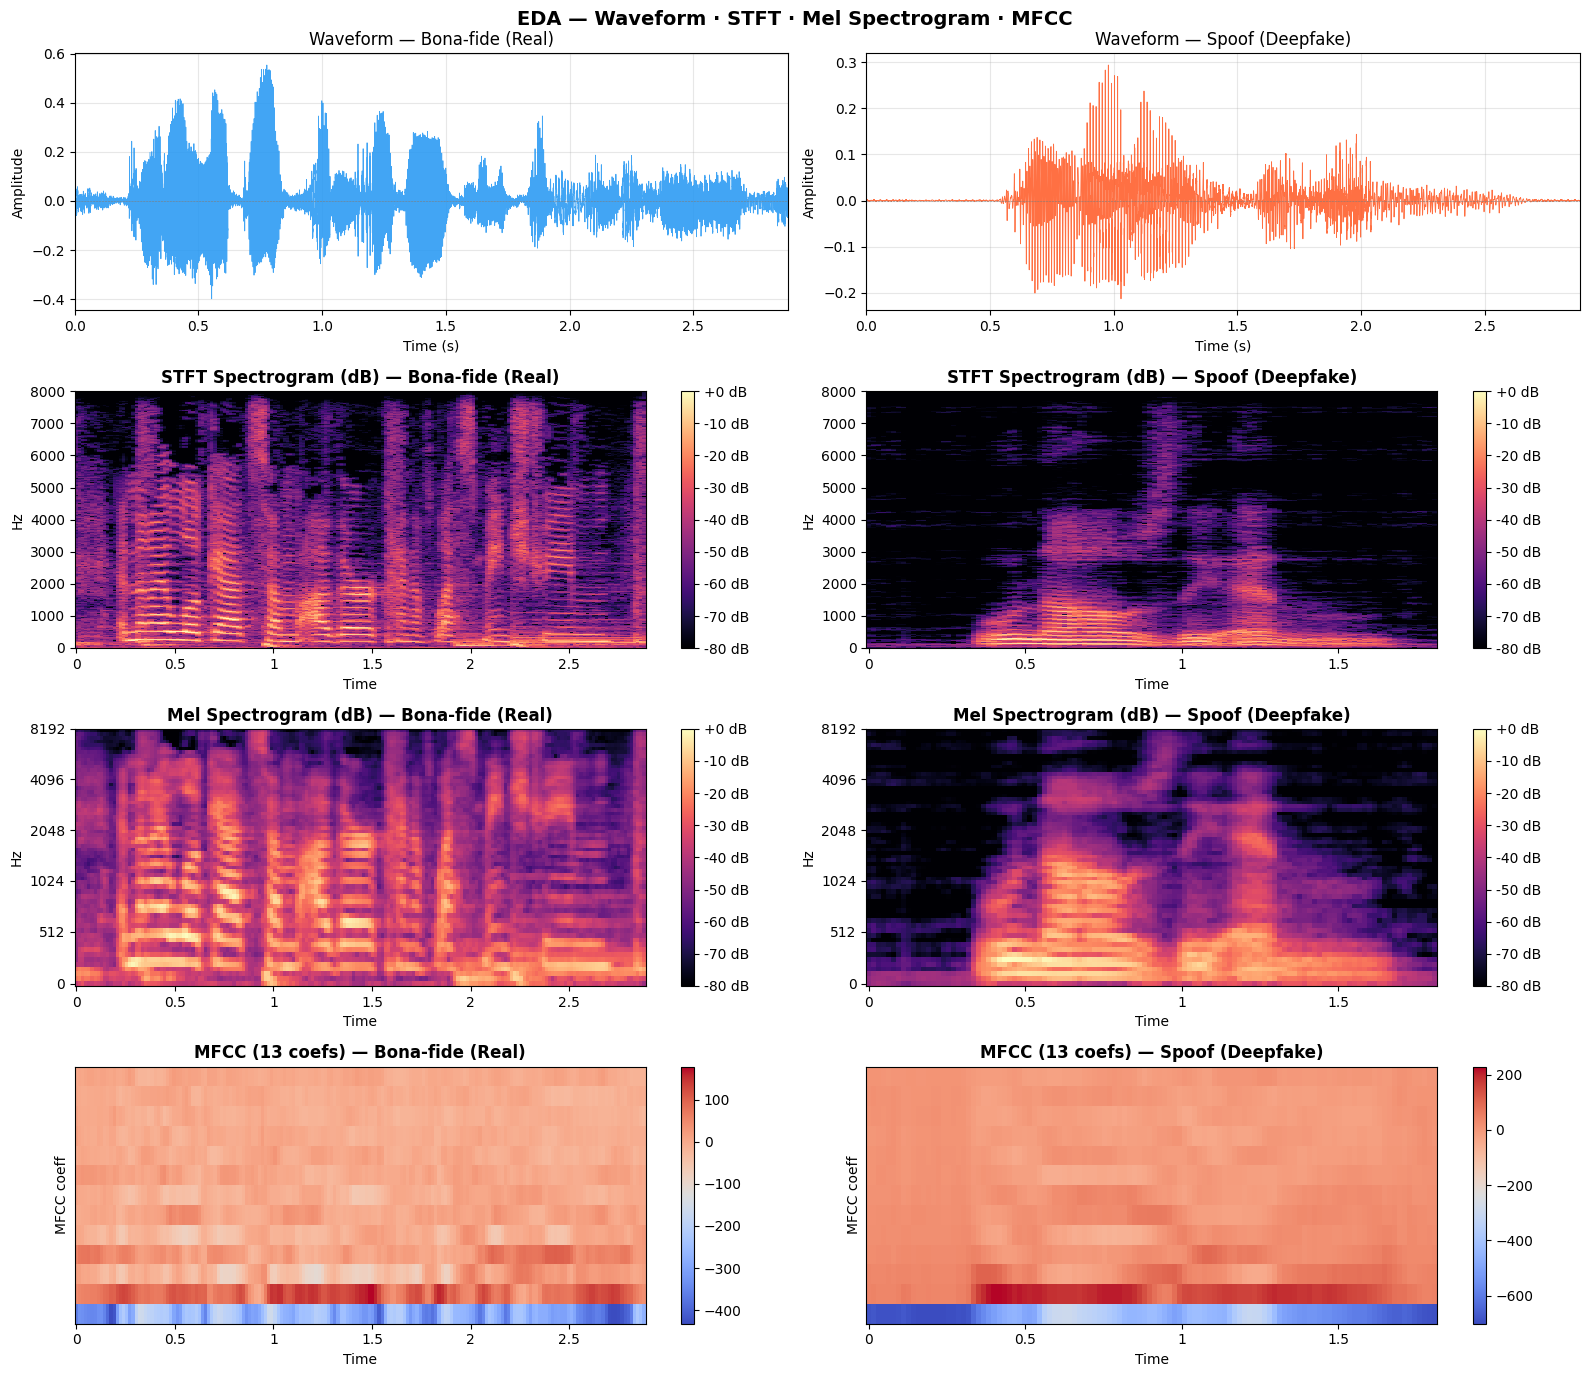

In [13]:
_titles = ["Bona-fide (Real)", "Spoof (Deepfake)"]
_ys     = [y_eda_real, y_eda_fake]
_feats  = [_fr, _ff]
_colors = [_C_REAL, _C_FAKE]

fig1, axes1 = plt.subplots(4, 2, figsize=(16, 14))
fig1.suptitle("EDA — Waveform · STFT · Mel Spectrogram · MFCC",
               fontsize=14, fontweight="bold")

for j in range(2):
    ax = axes1[0, j]
    t_ax = np.linspace(0, _DUR, len(_ys[j]))
    ax.plot(t_ax, _ys[j], color=_colors[j], lw=0.6, alpha=0.85)
    ax.axhline(0, color="gray", lw=0.4, ls="--")
    ax.set(title=f"Waveform — {_titles[j]}", xlabel="Time (s)", ylabel="Amplitude")
    ax.set_xlim(0, _DUR); ax.grid(True, alpha=0.3)

for j in range(2):
    ax = axes1[1, j]
    img = librosa.display.specshow(_feats[j]["stft_db"], sr=_SR, hop_length=_HOP,
                                    x_axis="time", y_axis="hz", ax=ax, cmap=_CMAP)
    ax.set_title(f"STFT Spectrogram (dB) — {_titles[j]}", fontweight="bold")
    fig1.colorbar(img, ax=ax, format="%+2.0f dB")

for j in range(2):
    ax = axes1[2, j]
    img = librosa.display.specshow(_feats[j]["mel_db"], sr=_SR, hop_length=_HOP,
                                    x_axis="time", y_axis="mel", ax=ax, cmap=_CMAP)
    ax.set_title(f"Mel Spectrogram (dB) — {_titles[j]}", fontweight="bold")
    fig1.colorbar(img, ax=ax, format="%+2.0f dB")

for j in range(2):
    ax = axes1[3, j]
    img = librosa.display.specshow(_feats[j]["mfcc"], x_axis="time",
                                    hop_length=_HOP, sr=_SR, ax=ax, cmap="coolwarm")
    ax.set_title(f"MFCC ({_NMFCC} coefs) — {_titles[j]}", fontweight="bold")
    ax.set_ylabel("MFCC coeff")
    fig1.colorbar(img, ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_fig1_waveform_stft_mel_mfcc.png"),
            dpi=150, bbox_inches="tight")
plt.show()


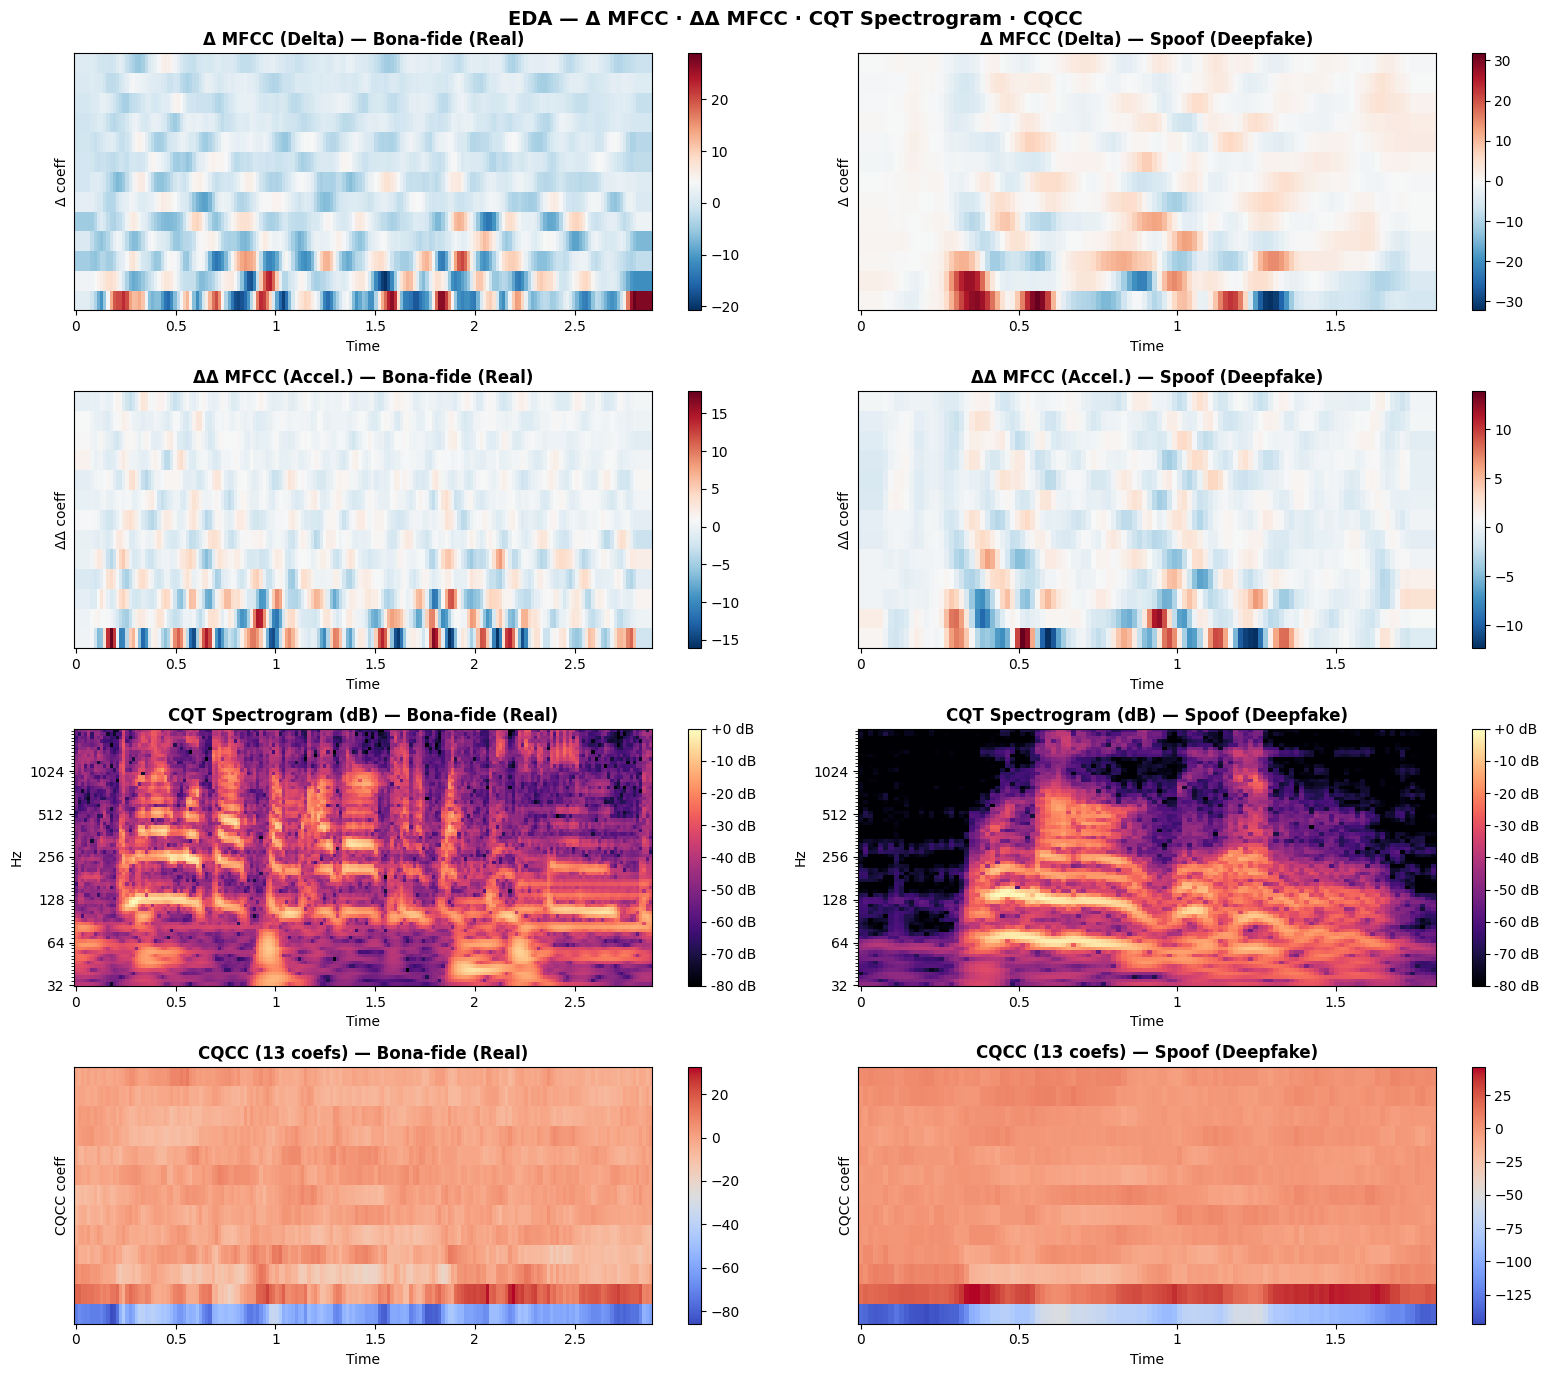

In [14]:
fig2, axes2 = plt.subplots(4, 2, figsize=(16, 14))
fig2.suptitle("EDA — Δ MFCC · ΔΔ MFCC · CQT Spectrogram · CQCC",
               fontsize=14, fontweight="bold")

_rows = [
    ("delta_mfcc",  "Δ MFCC (Delta)",        "RdBu_r",   "Δ coeff",    False),
    ("delta2_mfcc", "ΔΔ MFCC (Accel.)",       "RdBu_r",   "ΔΔ coeff",   False),
    ("cqt_db",      "CQT Spectrogram (dB)",   _CMAP,      None,          True),
    ("cqcc",        f"CQCC ({_NMFCC} coefs)", "coolwarm", "CQCC coeff", False),
]
for ri, (key, rtitle, cmap, ylabel, is_cqt) in enumerate(_rows):
    for j, (feat, title) in enumerate(zip(_feats, _titles)):
        ax = axes2[ri, j]
        kw = dict(x_axis="time", hop_length=_HOP, sr=_SR, ax=ax, cmap=cmap)
        if is_cqt:
            kw["y_axis"] = "cqt_hz"
        img = librosa.display.specshow(feat[key], **kw)
        ax.set_title(f"{rtitle} — {title}", fontweight="bold")
        if ylabel:
            ax.set_ylabel(ylabel)
        cb_fmt = "%+2.0f dB" if is_cqt else None
        fig2.colorbar(img, ax=ax, format=cb_fmt)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_fig2_delta_mfcc_cqt_cqcc.png"),
            dpi=150, bbox_inches="tight")
plt.show()


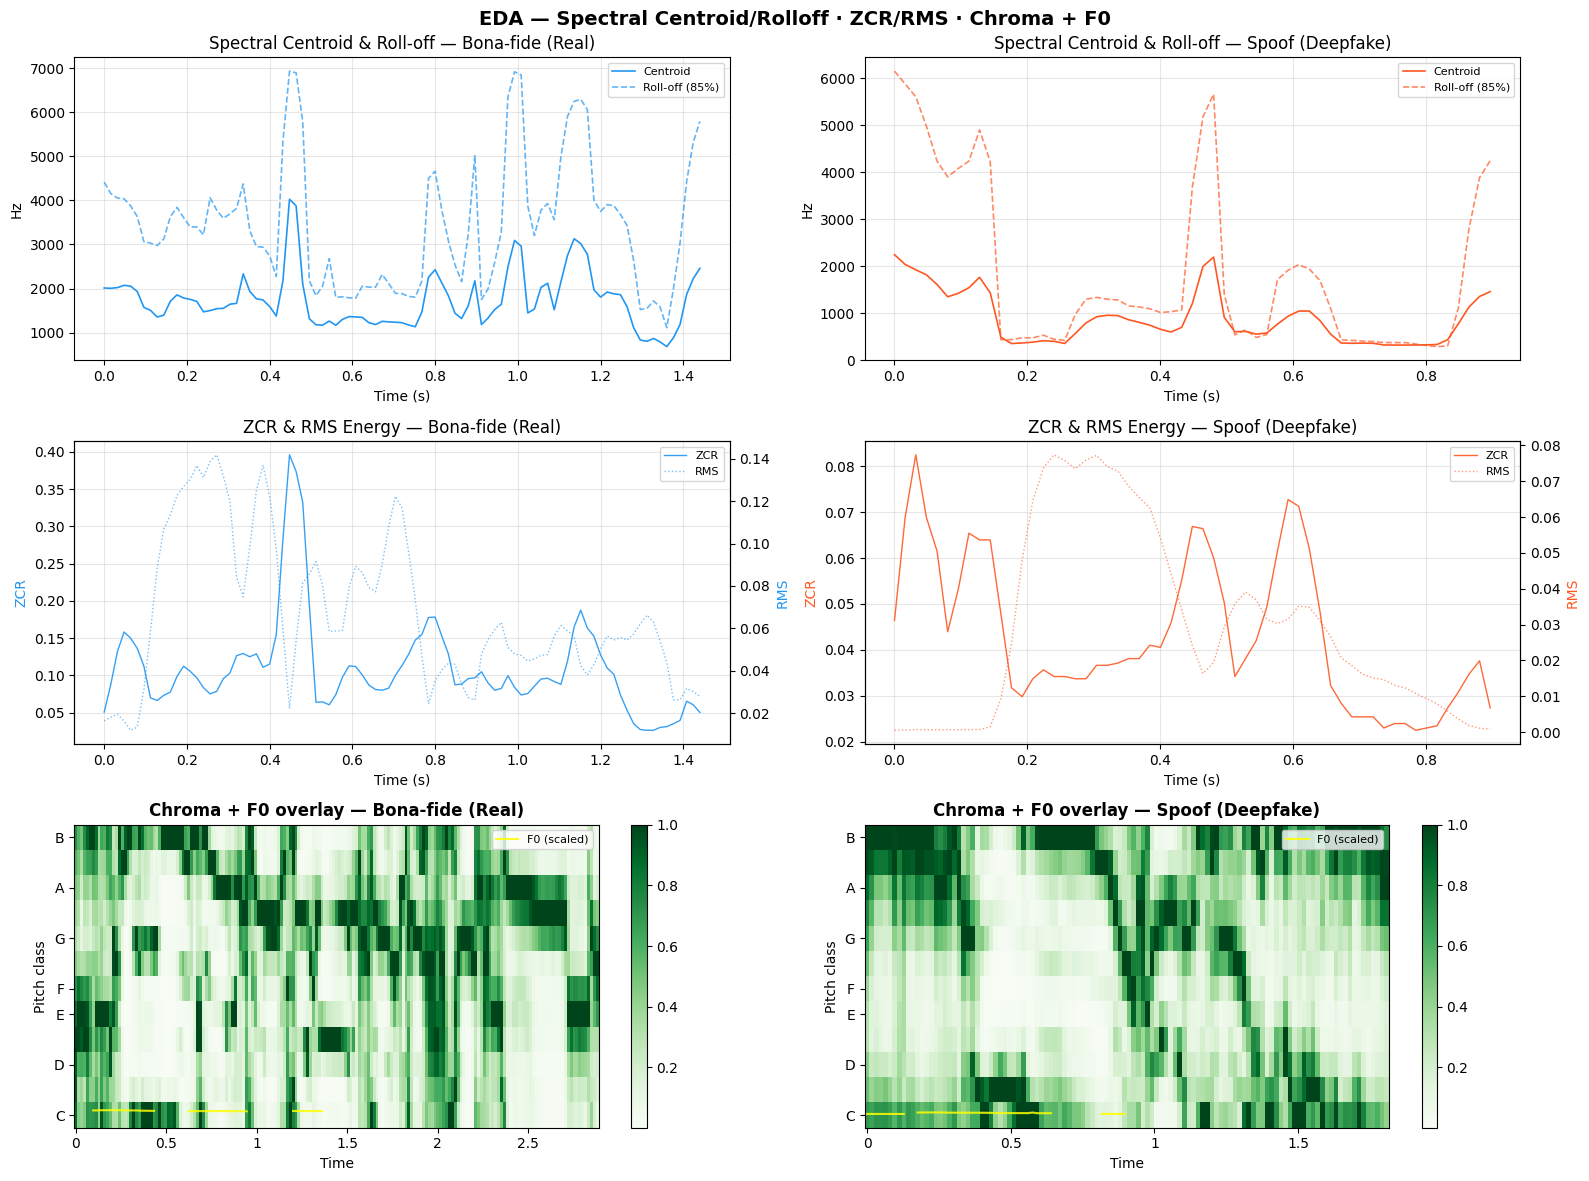

In [15]:
fig3, axes3 = plt.subplots(3, 2, figsize=(16, 12))
fig3.suptitle("EDA — Spectral Centroid/Rolloff · ZCR/RMS · Chroma + F0",
               fontsize=14, fontweight="bold")

for j, (feat, title, clr) in enumerate(zip(_feats, _titles, _colors)):
    ax = axes3[0, j]
    t_sc = librosa.times_like(feat["spec_centroid"], sr=_SR, hop_length=_HOP)
    ax.plot(t_sc, feat["spec_centroid"], color=clr, lw=1.2, label="Centroid")
    ax.plot(t_sc, feat["spec_rolloff"],  color=clr, lw=1.2, ls="--",
            alpha=0.7, label="Roll-off (85%)")
    ax.set(title=f"Spectral Centroid & Roll-off — {title}",
           xlabel="Time (s)", ylabel="Hz")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

for j, (feat, title, clr) in enumerate(zip(_feats, _titles, _colors)):
    ax  = axes3[1, j]
    ax2 = ax.twinx()
    t_zcr = librosa.times_like(feat["zcr"], sr=_SR, hop_length=_HOP)
    t_rms = librosa.times_like(feat["rms"], sr=_SR, hop_length=_HOP)
    ax.plot(t_zcr,  feat["zcr"], color=clr, lw=1.0, alpha=0.9,  label="ZCR")
    ax2.plot(t_rms, feat["rms"], color=clr, lw=1.0, ls=":", alpha=0.6, label="RMS")
    ax.set(title=f"ZCR & RMS Energy — {title}", xlabel="Time (s)")
    ax.set_ylabel("ZCR", color=clr); ax2.set_ylabel("RMS", color=clr)
    ax.grid(True, alpha=0.3)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, fontsize=8)

for j, (feat, title) in enumerate(zip(_feats, _titles)):
    ax = axes3[2, j]
    img = librosa.display.specshow(feat["chroma"], sr=_SR, hop_length=_HOP,
                                    x_axis="time", y_axis="chroma",
                                    ax=ax, cmap="Greens")
    f0_t = librosa.times_like(feat["f0"], sr=_SR, hop_length=_HOP)
    ax.plot(f0_t, (feat["f0"] / _SR) * 12, color="yellow", lw=1.5,
            alpha=0.85, label="F0 (scaled)")
    ax.set_title(f"Chroma + F0 overlay — {title}", fontweight="bold")
    fig3.colorbar(img, ax=ax); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_fig3_spectral_zcr_rms_chroma_f0.png"),
            dpi=150, bbox_inches="tight")
plt.show()


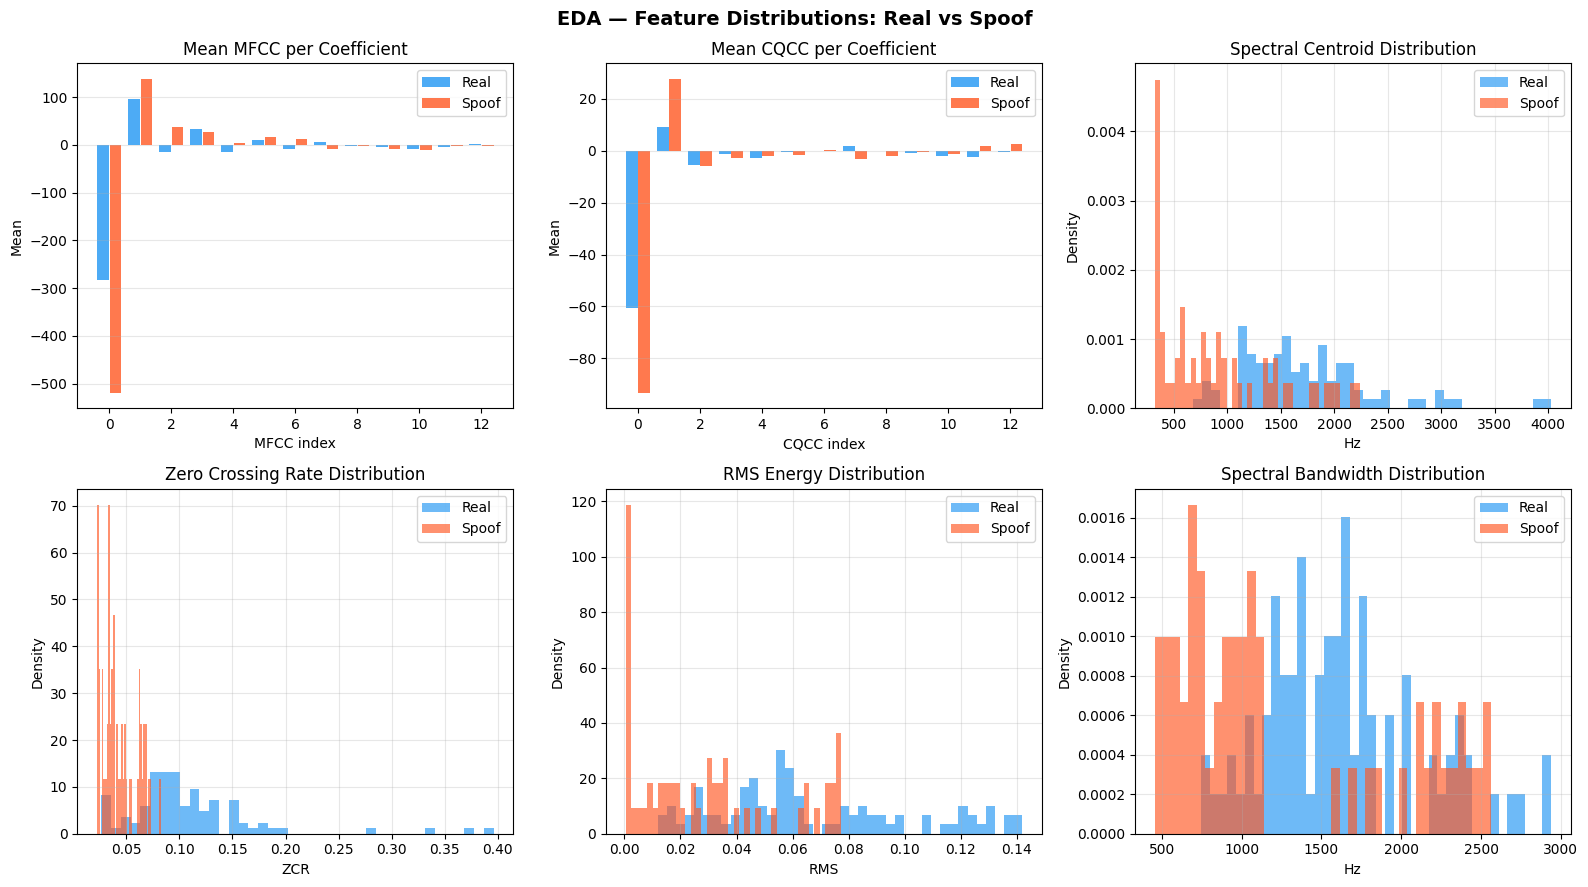

EDA complete — 4 figures saved to outputs


In [16]:
fig4, axes4 = plt.subplots(2, 3, figsize=(16, 9))
fig4.suptitle("EDA — Feature Distributions: Real vs Spoof",
               fontsize=14, fontweight="bold")

_x = np.arange(_NMFCC)

ax = axes4[0, 0]
ax.bar(_x-0.2, _fr["mfcc"].mean(axis=1), 0.38, color=_C_REAL, alpha=0.8, label="Real")
ax.bar(_x+0.2, _ff["mfcc"].mean(axis=1), 0.38, color=_C_FAKE, alpha=0.8, label="Spoof")
ax.set(title="Mean MFCC per Coefficient", xlabel="MFCC index", ylabel="Mean")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

ax = axes4[0, 1]
ax.bar(_x-0.2, _fr["cqcc"].mean(axis=1), 0.38, color=_C_REAL, alpha=0.8, label="Real")
ax.bar(_x+0.2, _ff["cqcc"].mean(axis=1), 0.38, color=_C_FAKE, alpha=0.8, label="Spoof")
ax.set(title="Mean CQCC per Coefficient", xlabel="CQCC index", ylabel="Mean")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

ax = axes4[0, 2]
ax.hist(_fr["spec_centroid"], bins=40, color=_C_REAL, alpha=0.65, density=True, label="Real")
ax.hist(_ff["spec_centroid"], bins=40, color=_C_FAKE, alpha=0.65, density=True, label="Spoof")
ax.set(title="Spectral Centroid Distribution", xlabel="Hz", ylabel="Density")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes4[1, 0]
ax.hist(_fr["zcr"], bins=40, color=_C_REAL, alpha=0.65, density=True, label="Real")
ax.hist(_ff["zcr"], bins=40, color=_C_FAKE, alpha=0.65, density=True, label="Spoof")
ax.set(title="Zero Crossing Rate Distribution", xlabel="ZCR", ylabel="Density")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes4[1, 1]
ax.hist(_fr["rms"], bins=40, color=_C_REAL, alpha=0.65, density=True, label="Real")
ax.hist(_ff["rms"], bins=40, color=_C_FAKE, alpha=0.65, density=True, label="Spoof")
ax.set(title="RMS Energy Distribution", xlabel="RMS", ylabel="Density")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes4[1, 2]
ax.hist(_fr["spec_bandwidth"], bins=40, color=_C_REAL, alpha=0.65, density=True, label="Real")
ax.hist(_ff["spec_bandwidth"], bins=40, color=_C_FAKE, alpha=0.65, density=True, label="Spoof")
ax.set(title="Spectral Bandwidth Distribution", xlabel="Hz", ylabel="Density")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_fig4_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("EDA complete — 4 figures saved to", OUTPUT_DIR)


In [17]:
def _featurize_row_to_vec(feats):
    return np.concatenate([feats["mfcc"], feats["cqcc"], feats["lfcc"],
                            feats["spectral"], feats["prosody"], feats["physics"],
                            feats["xlsr"] if feats["xlsr"].shape[0] > 0
                            else np.zeros(DIM_XLSR, dtype=np.float32)])


def build_feature_cache(split_df, cache_path, augment=False):
    """"`augment` (only ever True for the train split) oversamples
    the minority (spoof) class with waveform-augmented copies of existing
    spoof clips -- noise/pitch/stretch/gain via AudioAugmentor -- until spoof
    count is within AUGMENT_TARGET_RATIO of bona-fide count. Val/test are
    never augmented, so evaluation numbers stay honest."""
    if os.path.exists(cache_path):
        print(f"[cache hit] {cache_path}")
        data = np.load(cache_path, allow_pickle=True)
        return data["X"], data["y"], data["speakers"]

    X, y, speakers = [], [], []
    n = len(split_df)
    for i, row in split_df.iterrows():
        feats = feature_extractor.combineFeatures(row["filepath"])
        X.append(_featurize_row_to_vec(feats))
        y.append(row["target"])
        speakers.append(row["speaker"])
        if (i + 1) % 150 == 0 or (i + 1) == n:
            print(f"  extracted {i+1}/{n}")

    if augment and USE_AUGMENTATION:
        y_arr_tmp = np.array(y)
        n_bona = int((y_arr_tmp == LABEL_MAP["bona-fide"]).sum())
        n_spoof = int((y_arr_tmp == LABEL_MAP["spoof"]).sum())
        n_needed = max(0, int(n_bona * AUGMENT_TARGET_RATIO) - n_spoof)
        print(f"[augment] train spoof={n_spoof} bona-fide={n_bona} "
              f"-> generating {n_needed} augmented spoof samples to reach target ratio {AUGMENT_TARGET_RATIO}")
        if n_needed > 0:
            spoof_rows = split_df[split_df["target"] == LABEL_MAP["spoof"]].reset_index(drop=True)
            aug_rng = np.random.RandomState(AUGMENT_SEED)
            for j in range(n_needed):
                src_row = spoof_rows.iloc[aug_rng.randint(len(spoof_rows))]
                wav_tensor = AudioProcessor.process(src_row["filepath"])
                y_orig = wav_tensor.squeeze(0).numpy()
                y_aug = AudioAugmentor.augment(y_orig, aug_rng)
                feats = feature_extractor.combineFeaturesFromArray(y_aug)
                X.append(_featurize_row_to_vec(feats))
                y.append(src_row["target"])
                speakers.append(src_row["speaker"]) 
                if (j + 1) % 150 == 0 or (j + 1) == n_needed:
                    print(f"  augmented {j+1}/{n_needed}")

    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    speakers = np.array(speakers)
    np.savez_compressed(cache_path, X=X, y=y, speakers=speakers)
    return X, y, speakers

print("Building feature caches (this runs the full hybrid extractor once per split)...")

X_train, y_train, spk_train = build_feature_cache(train_df, os.path.join(OUTPUT_DIR, f"feat_train_{FEATURE_CACHE_VERSION}.npz"), augment=True)
X_val,   y_val,   spk_val   = build_feature_cache(val_df,   os.path.join(OUTPUT_DIR, f"feat_val_{FEATURE_CACHE_VERSION}.npz"))
X_test,  y_test,  spk_test  = build_feature_cache(test_df,  os.path.join(OUTPUT_DIR, f"feat_test_{FEATURE_CACHE_VERSION}.npz"))
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Building feature caches (this runs the full hybrid extractor once per split)...
  extracted 150/22239
  extracted 300/22239
  extracted 450/22239
  extracted 600/22239
  extracted 750/22239
  extracted 900/22239
  extracted 1050/22239
  extracted 1200/22239
  extracted 1350/22239
  extracted 1500/22239
  extracted 1650/22239
  extracted 1800/22239
  extracted 1950/22239
  extracted 2100/22239
  extracted 2250/22239
  extracted 2400/22239
  extracted 2550/22239
  extracted 2700/22239
  extracted 2850/22239
  extracted 3000/22239
  extracted 3150/22239
  extracted 3300/22239
  extracted 3450/22239
  extracted 3600/22239
  extracted 3750/22239
  extracted 3900/22239
  extracted 4050/22239
  extracted 4200/22239
  extracted 4350/22239
  extracted 4500/22239
  extracted 4650/22239
  extracted 4800/22239
  extracted 4950/22239
  extracted 5100/22239
  extracted 5250/22239
  extracted 5400/22239
  extracted 5550/22239
  extracted 5700/22239
  extracted 5850/22239
  extracted 6000/22239
  extr

In [18]:
GROUP_SLICES = {}
_off = 0
for name, d in FEATURE_GROUP_DIMS.items():
    dd = d if d > 0 else DIM_XLSR  
    GROUP_SLICES[name] = (_off, _off + dd)
    _off += dd
print(GROUP_SLICES)
assert _off == X_train.shape[1], f"{_off} != {X_train.shape[1]}"

{'mfcc': (0, 80), 'cqcc': (80, 160), 'lfcc': (160, 240), 'spectral': (240, 254), 'prosody': (254, 258), 'physics': (258, 262), 'xlsr': (262, 1286)}


In [19]:
class FeatureFusion(nn.Module):
    def __init__(self, group_slices):
        super().__init__()
      
        self.group_slices = {name: (s, e) for name, (s, e) in group_slices.items() if e > s}
        self.group_names = list(self.group_slices.keys())
        self.norms = nn.ModuleDict({
            name: nn.LayerNorm(end - start) for name, (start, end) in self.group_slices.items()
        })
       
        total_dim = sum(end - start for start, end in self.group_slices.values())
        self.gate = nn.Sequential(
            nn.Linear(total_dim, len(self.group_names)),
        )

    def concatenateFeatures(self, x):
        return x 

    def normalizeFeatures(self, x):
        parts = []
        for name in self.group_names:
            start, end = self.group_slices[name]
            parts.append(self.norms[name](x[:, start:end]))
        return torch.cat(parts, dim=1)

    def attentionFusion(self, x_norm):
        weights = torch.softmax(self.gate(x_norm), dim=1)  
        parts = []
        for i, name in enumerate(self.group_names):
            start, end = self.group_slices[name]
            w = weights[:, i:i+1]
            parts.append(x_norm[:, start:end] * w)
        return torch.cat(parts, dim=1), weights

    def forward(self, x):
        x = self.concatenateFeatures(x)
        x_norm = self.normalizeFeatures(x)
        fused, weights = self.attentionFusion(x_norm)
        return fused, weights


feature_fusion = FeatureFusion(GROUP_SLICES).to(DEVICE)
print(feature_fusion)


FeatureFusion(
  (norms): ModuleDict(
    (mfcc): LayerNorm((80,), eps=1e-05, elementwise_affine=True)
    (cqcc): LayerNorm((80,), eps=1e-05, elementwise_affine=True)
    (lfcc): LayerNorm((80,), eps=1e-05, elementwise_affine=True)
    (spectral): LayerNorm((14,), eps=1e-05, elementwise_affine=True)
    (prosody): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
    (physics): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
    (xlsr): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (gate): Sequential(
    (0): Linear(in_features=1286, out_features=7, bias=True)
  )
)


In [20]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=PROJ_HIDDEN, out_dim=EMBED_DIM):
        super().__init__()
        self.linear1 = nn.Linear(in_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act = nn.ReLU(inplace=True)
        self.linear2 = nn.Linear(hidden_dim, out_dim)

    def linearProjection(self, x):
        return self.linear1(x)

    def batchNormalize(self, x):
        return self.act(self.bn1(x))

    def generateEmbedding(self, x):
        emb = self.linear2(x)
        return F.normalize(emb, dim=1)  

    def forward(self, x):
        x = self.linearProjection(x)
        x = self.batchNormalize(x)
        return self.generateEmbedding(x)


projection_head = ProjectionHead(TOTAL_RAW_DIM).to(DEVICE)
print(projection_head)


ProjectionHead(
  (linear1): Linear(in_features=1286, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): ReLU(inplace=True)
  (linear2): Linear(in_features=512, out_features=256, bias=True)
)


In [21]:
class GeneralEmbeddingModel(nn.Module):
    def __init__(self, fusion, projector):
        super().__init__()
        self.fusion = fusion
        self.projector = projector
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        fused, attn_weights = self.fusion(x)
        embedding = self.projector(fused)
        logits = self.classifier(embedding)
        return embedding, logits, attn_weights


general_model = GeneralEmbeddingModel(feature_fusion, projection_head).to(DEVICE)
print(general_model)


GeneralEmbeddingModel(
  (fusion): FeatureFusion(
    (norms): ModuleDict(
      (mfcc): LayerNorm((80,), eps=1e-05, elementwise_affine=True)
      (cqcc): LayerNorm((80,), eps=1e-05, elementwise_affine=True)
      (lfcc): LayerNorm((80,), eps=1e-05, elementwise_affine=True)
      (spectral): LayerNorm((14,), eps=1e-05, elementwise_affine=True)
      (prosody): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
      (physics): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
      (xlsr): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (gate): Sequential(
      (0): Linear(in_features=1286, out_features=7, bias=True)
    )
  )
  (projector): ProjectionHead(
    (linear1): Linear(in_features=1286, out_features=512, bias=True)
    (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU(inplace=True)
    (linear2): Linear(in_features=512, out_features=256, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_fe

In [22]:
class TabularRATDataset(Dataset):
    def __init__(self, X, y, speakers):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.speakers = speakers

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.speakers[idx]


train_loader = DataLoader(TabularRATDataset(X_train, y_train, spk_train),
                           batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TabularRATDataset(X_val, y_val, spk_val),
                           batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TabularRATDataset(X_test, y_test, spk_test),
                           batch_size=BATCH_SIZE, shuffle=False)


def createPositivePairs(embeddings, labels, speakers):
    """For each anchor, pick another sample with the same label (same speaker
    preferred) as the positive. Returns index tensor aligned with the batch."""
    idx = torch.arange(len(labels))
    pos_idx = idx.clone()
    labels_np = labels.cpu().numpy()
    speakers_np = np.asarray(speakers)
    for i in range(len(labels)):
        same_speaker = np.where((speakers_np == speakers_np[i]) & (labels_np == labels_np[i].item()))[0]
        same_speaker = same_speaker[same_speaker != i]
        if len(same_speaker) > 0:
            pos_idx[i] = int(np.random.choice(same_speaker))
        else:
            same_label = np.where(labels_np == labels_np[i].item())[0]
            same_label = same_label[same_label != i]
            pos_idx[i] = int(np.random.choice(same_label)) if len(same_label) else i
    return pos_idx


def createNegativePairs(embeddings, labels, speakers):
    """Negative = opposite class (spoof for a genuine anchor, or vice versa),
    falling back to a different speaker of the same class if needed."""
    idx = torch.arange(len(labels))
    neg_idx = idx.clone()
    labels_np = labels.cpu().numpy()
    speakers_np = np.asarray(speakers)
    for i in range(len(labels)):
        opp_label = np.where(labels_np != labels_np[i].item())[0]
        if len(opp_label) > 0:
            neg_idx[i] = int(np.random.choice(opp_label))
        else:
            diff_speaker = np.where(speakers_np != speakers_np[i])[0]
            neg_idx[i] = int(np.random.choice(diff_speaker)) if len(diff_speaker) else i
    return neg_idx


triplet_loss_fn = nn.TripletMarginLoss(margin=TRIPLET_MARGIN, p=2)

def computeContrastiveLoss(embeddings, labels, speakers):
    pos_idx = createPositivePairs(embeddings, labels, speakers)
    neg_idx = createNegativePairs(embeddings, labels, speakers)
    anchor = embeddings
    positive = embeddings[pos_idx]
    negative = embeddings[neg_idx]
    return triplet_loss_fn(anchor, positive, negative)

print("Contrastive pairing utilities ready.")


Contrastive pairing utilities ready.


Class counts (train) bona-fide=15327 spoof=15327 -> CE weights=[1. 1.]
Epoch 01/12  train_loss=0.0818 train_acc=0.9801  val_loss=0.5273 val_acc=0.9088
  ✓ saved best general model (val_loss=0.5273)
Epoch 02/12  train_loss=0.0370 train_acc=0.9919  val_loss=0.3877 val_acc=0.9252
  ✓ saved best general model (val_loss=0.3877)
Epoch 03/12  train_loss=0.0309 train_acc=0.9930  val_loss=0.6025 val_acc=0.8852
Epoch 04/12  train_loss=0.0219 train_acc=0.9949  val_loss=0.2894 val_acc=0.9466
  ✓ saved best general model (val_loss=0.2894)
Epoch 05/12  train_loss=0.0183 train_acc=0.9959  val_loss=0.4083 val_acc=0.9214
Epoch 06/12  train_loss=0.0129 train_acc=0.9970  val_loss=0.5142 val_acc=0.9105
Epoch 07/12  train_loss=0.0141 train_acc=0.9963  val_loss=0.3725 val_acc=0.9399
Epoch 08/12  train_loss=0.0079 train_acc=0.9982  val_loss=0.3832 val_acc=0.9367
Epoch 09/12  train_loss=0.0089 train_acc=0.9981  val_loss=0.3459 val_acc=0.9399
  Early stopping at epoch 9


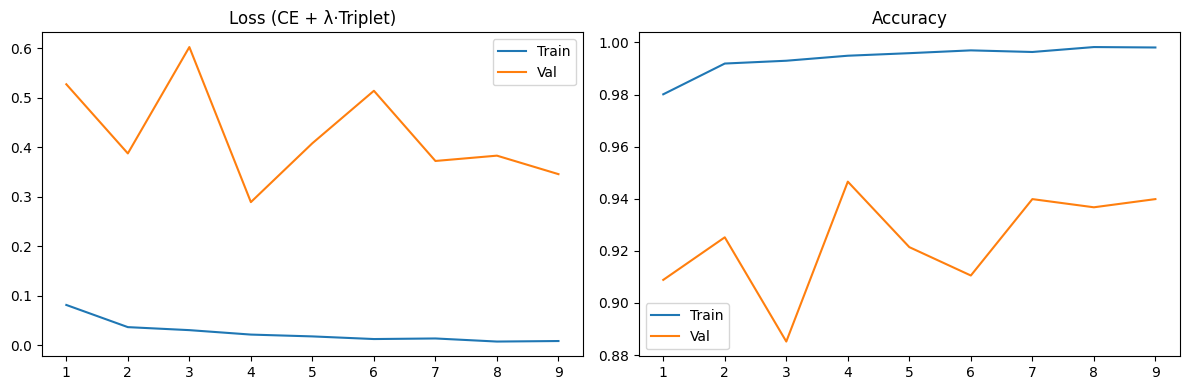

In [23]:

for _p in general_model.parameters():
    _p.requires_grad = True

_cls_counts = np.bincount(y_train, minlength=2).astype(np.float32)
_cls_weights = torch.tensor(_cls_counts.sum() / (2.0 * _cls_counts), dtype=torch.float32).to(DEVICE)
print(f"Class counts (train) bona-fide={int(_cls_counts[0])} spoof={int(_cls_counts[1])} "
      f"-> CE weights={_cls_weights.cpu().numpy()}")
ce_loss_fn = nn.CrossEntropyLoss(weight=_cls_weights)
optimizer = optim.Adam(general_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
patience, patience_counter = 5, 0

def run_epoch(loader, train_mode):
    general_model.train(train_mode)
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb, spk in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            embedding, logits, _ = general_model(xb)
            ce = ce_loss_fn(logits, yb)
            triplet = computeContrastiveLoss(embedding, yb, spk)
            loss = ce + LAMBDA_TRIPLET * triplet
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(general_model.parameters(), max_norm=1.0)
                optimizer.step()           
        total_loss += loss.item() * len(yb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    scheduler.step()

    history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss);     history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:02d}/{EPOCHS}  train_loss={train_loss:.4f} train_acc={train_acc:.4f}  "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss, patience_counter = val_loss, 0
        torch.save(general_model.state_dict(), EMBED_MODEL_PATH)
        print(f"  ✓ saved best general model (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history["train_loss"]) + 1)
ax1.plot(ep, history["train_loss"], label="Train"); ax1.plot(ep, history["val_loss"], label="Val")
ax1.set_title("Loss (CE + λ·Triplet)"); ax1.legend()
ax2.plot(ep, history["train_acc"], label="Train"); ax2.plot(ep, history["val_acc"], label="Val")
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout(); plt.savefig(HISTORY_PLOT_PATH, dpi=150); plt.show()


                  precision    recall  f1-score   support

bona-fide (real)       0.95      0.95      0.95      2501
spoof (deepfake)       0.95      0.95      0.95      2267

        accuracy                           0.95      4768
       macro avg       0.95      0.95      0.95      4768
    weighted avg       0.95      0.95      0.95      4768


AUC = 0.9887   EER = 4.96%  (threshold=0.2438)

--- Classification report @ EER threshold (0.2438) instead of default 0.5 ---
                  precision    recall  f1-score   support

bona-fide (real)       0.95      0.95      0.95      2501
spoof (deepfake)       0.95      0.95      0.95      2267

        accuracy                           0.95      4768
       macro avg       0.95      0.95      0.95      4768
    weighted avg       0.95      0.95      0.95      4768



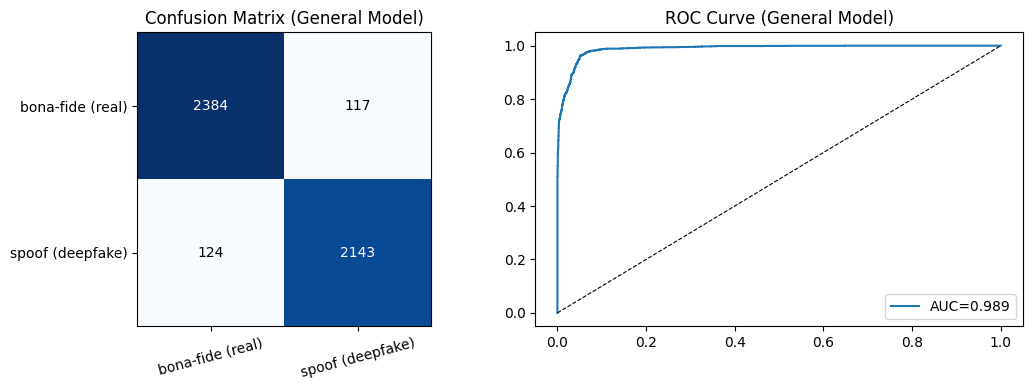

In [24]:
general_model.load_state_dict(torch.load(EMBED_MODEL_PATH, map_location=DEVICE))
general_model.eval()

all_labels, all_probs, all_embeddings = [], [], []
with torch.no_grad():
    for xb, yb, spk in test_loader:
        xb = xb.to(DEVICE)
        embedding, logits, _ = general_model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # P(spoof)
        all_probs.extend(probs.tolist())
        all_labels.extend(yb.numpy().tolist())
        all_embeddings.append(embedding.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_embeddings = np.concatenate(all_embeddings, axis=0)
all_preds = (all_probs >= 0.5).astype(int)

print(classification_report(all_labels, all_preds, target_names=list(INVERSE_LABEL_MAP.values())))

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
auc_val = roc_auc_score(all_labels, all_probs)
fnr = 1 - tpr
finite = np.isfinite(thresholds)
thr, fpr_, fnr_ = thresholds[finite], fpr[finite], fnr[finite]
order = np.argsort(thr); thr, fpr_, fnr_ = thr[order], fpr_[order], fnr_[order]
eer_func = interp1d(thr, fpr_ - fnr_)
eer_thresh = brentq(eer_func, thr[0], thr[-1])
eer = float(interp1d(thr, fpr_)(eer_thresh))
print(f"\nAUC = {auc_val:.4f}   EER = {eer*100:.2f}%  (threshold={eer_thresh:.4f})")

all_preds_eer = (all_probs >= eer_thresh).astype(int)
print(f"\n--- Classification report @ EER threshold ({eer_thresh:.4f}) instead of default 0.5 ---")
print(classification_report(all_labels, all_preds_eer, target_names=list(INVERSE_LABEL_MAP.values())))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cm = confusion_matrix(all_labels, all_preds)
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(list(INVERSE_LABEL_MAP.values()), rotation=15)
axes[0].set_yticklabels(list(INVERSE_LABEL_MAP.values()))
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "black")
axes[0].set_title("Confusion Matrix (General Model)")

axes[1].plot(fpr, tpr, label=f"AUC={auc_val:.3f}")
axes[1].plot([0,1],[0,1],"k--", lw=0.8)
axes[1].set_title("ROC Curve (General Model)"); axes[1].legend()
plt.tight_layout(); plt.show()


In [25]:
class MemoryBank:
    """LLD `SpeakerMemory` (Module 6, novel) — persistent, FAISS-indexed, per-speaker
    store of trusted embeddings. Extended with `age_weight`, `physics_vector`, and
    `cluster_size` columns so it can support Memory Aging (Module 13) and Prototype
    Memory Compression (Module 14) on top of the base insert/retrieve behaviour."""

    def __init__(self, dim=EMBED_DIM, physics_dim=DIM_PHYSICS,
                 db_path=MEMORY_DB_PATH, index_path=FAISS_INDEX_PATH,
                 reset_db=RESET_MEMORY_DB):
        self.dim = dim
        self.physics_dim = physics_dim
        self.db_path = db_path
        self.index_path = index_path
        self._init_db(reset=reset_db)
        self.buildIndex()

  
    def _init_db(self, reset=True):
        """`reset=True` wipes any pre-existing DB (fine for a fresh experimental run,
        but destroys all previously-learned speaker memory). In deployment, construct
        MemoryBank(reset_db=False) — or set the RESET_MEMORY_DB config flag — so
        memory persists across process restarts instead of resetting every run."""
        if reset and os.path.exists(self.db_path):
            print(f"[MemoryBank] reset_db=True -> wiping existing memory at {self.db_path}")
            os.remove(self.db_path)
        elif os.path.exists(self.db_path):
            print(f"[MemoryBank] reset_db=False -> reusing existing memory at {self.db_path}")
        self.conn = sqlite3.connect(self.db_path)
        self.conn.execute("""
            CREATE TABLE IF NOT EXISTS embeddings (
                id             INTEGER PRIMARY KEY AUTOINCREMENT,
                speaker_id     TEXT NOT NULL,
                embedding      BLOB NOT NULL,
                timestamp      REAL NOT NULL,
                confidence     REAL NOT NULL,
                age_weight     REAL NOT NULL DEFAULT 1.0,
                physics_vector BLOB,
                cluster_size   INTEGER NOT NULL DEFAULT 1
            )
        """)
        self.conn.commit()

   
    def buildIndex(self):
        if HAS_FAISS:
            self.index = faiss.IndexFlatIP(self.dim)
        else:
            self.index = None  # brute-force numpy fallback
        self._id_order = []
        self._refresh_from_db()

    def _refresh_from_db(self):
        rows = self.conn.execute("SELECT id, embedding FROM embeddings ORDER BY id").fetchall()
        self._id_order = [r[0] for r in rows]
        if len(rows) == 0:
            if HAS_FAISS:
                self.index = faiss.IndexFlatIP(self.dim)
            self._matrix = np.zeros((0, self.dim), dtype=np.float32)
            return
        mat = np.stack([np.frombuffer(r[1], dtype=np.float32) for r in rows]).astype(np.float32)
        self._matrix = mat
        if HAS_FAISS:
            self.index = faiss.IndexFlatIP(self.dim)
            self.index.add(mat)

    def rebuildIndex(self):
        """Full-table reload of the global FAISS/_matrix index. Expensive (O(n) scan
        + full FAISS rebuild across ALL speakers) -- nothing in this notebook's
        retrieval path (getSpeakerRows/getSpeakerMatrix, used by every Top-K /
        physics-mean / similarity lookup) actually reads self._matrix or self.index,
        so this should be called sparingly (e.g. once at the end of a replay), not
        after every single write."""
        self._refresh_from_db()

   
    def addEmbedding(self, speaker_id, embedding, confidence, timestamp=None,
                      physics_vector=None, cluster_size=1, age_weight=1.0):
        """NOTE: does NOT rebuild the global FAISS/_matrix index (see rebuildIndex()
        docstring) -- every retrieval path (getSpeakerRows/getSpeakerMatrix) reads
        straight from SQLite by speaker_id, so reindexing on every single insert
        was pure O(n) wasted work per write (O(n^2) over a full replay) for an
        index nothing ever queries. Call rebuildIndex() explicitly if/when you
        actually need the global index refreshed."""
        timestamp = time.time() if timestamp is None else timestamp
        emb = np.asarray(embedding, dtype=np.float32)
        emb = emb / (np.linalg.norm(emb) + 1e-9)
        phys_blob = None
        if physics_vector is not None:
            phys_blob = np.asarray(physics_vector, dtype=np.float32).tobytes()
        self.conn.execute(
            "INSERT INTO embeddings (speaker_id, embedding, timestamp, confidence, "
            "age_weight, physics_vector, cluster_size) VALUES (?, ?, ?, ?, ?, ?, ?)",
            (speaker_id, emb.tobytes(), timestamp, float(confidence),
             float(age_weight), phys_blob, int(cluster_size)),
        )
        self.conn.commit()

    def deleteEmbedding(self, entry_id):
        self.conn.execute("DELETE FROM embeddings WHERE id = ?", (entry_id,))
        self.conn.commit()

    def removeOutdatedEntries(self, speaker_id, max_entries=MAX_ENTRIES_PER_SPEAKER):
        """Hard safety-net cap. Prototype Memory Compression (Module 14) normally
        keeps a speaker's raw-entry count well under this ceiling; this only fires
        if compression is skipped or unavailable (e.g. sklearn missing)."""
        rows = self.conn.execute(
            "SELECT id FROM embeddings WHERE speaker_id = ? ORDER BY timestamp DESC", (speaker_id,)
        ).fetchall()
        if len(rows) > max_entries:
            stale_ids = [r[0] for r in rows[max_entries:]]
            self.conn.executemany("DELETE FROM embeddings WHERE id = ?", [(i,) for i in stale_ids])
            self.conn.commit()

    def replaceSpeakerEntries(self, speaker_id, centroids, confidences, cluster_sizes,
                                physics_centroids=None, now=None):
        """Prototype Memory Compression write-back (Module 14 / `replacePrototype`):
        atomically swaps a speaker's raw embeddings for ~PROTOTYPE_TARGET_COUNT
        representative, cluster-weighted centroids."""
        now = now if now is not None else time.time()
        self.conn.execute("DELETE FROM embeddings WHERE speaker_id = ?", (speaker_id,))
        for i in range(len(centroids)):
            emb = np.asarray(centroids[i], dtype=np.float32)
            emb = emb / (np.linalg.norm(emb) + 1e-9)
            phys = physics_centroids[i] if physics_centroids is not None else None
            phys_blob = np.asarray(phys, dtype=np.float32).tobytes() if phys is not None else None
            self.conn.execute(
                "INSERT INTO embeddings (speaker_id, embedding, timestamp, confidence, "
                "age_weight, physics_vector, cluster_size) VALUES (?, ?, ?, ?, ?, ?, ?)",
                (speaker_id, emb.tobytes(), now, float(confidences[i]), 1.0, phys_blob, int(cluster_sizes[i])),
            )
        self.conn.commit()

    def bulkUpdateAgeWeights(self, updates):
        """updates: list of (age_weight, id) tuples — used by MemoryAgingManager."""
        if updates:
            self.conn.executemany("UPDATE embeddings SET age_weight = ? WHERE id = ?", updates)
            self.conn.commit()

    def updateSpeakerProfile(self, speaker_id, embedding, confidence, physics_vector=None):
        """Legacy convenience wrapper (plain insert + hard-cap safety net). The main
        deployment loop instead goes through `MemoryUpdateController.processUpdate`,
        which layers Aging + Prototype Compression on top of this."""
        self.addEmbedding(speaker_id, embedding, confidence, physics_vector=physics_vector)
        self.removeOutdatedEntries(speaker_id)

    
    def computeSimilarity(self, query_emb, candidate_mat):
        q = query_emb / (np.linalg.norm(query_emb) + 1e-9)
        c = candidate_mat / (np.linalg.norm(candidate_mat, axis=1, keepdims=True) + 1e-9)
        return c @ q

    def getSpeakerRows(self, speaker_id):
        rows = self.conn.execute(
            "SELECT id, embedding, timestamp, confidence, age_weight, physics_vector, cluster_size "
            "FROM embeddings WHERE speaker_id = ?", (speaker_id,)
        ).fetchall()
        out = []
        for r in rows:
            out.append({
                "id": r[0],
                "embedding": np.frombuffer(r[1], dtype=np.float32),
                "timestamp": r[2],
                "confidence": r[3],
                "age_weight": r[4],
                "physics_vector": np.frombuffer(r[5], dtype=np.float32) if r[5] is not None else None,
                "cluster_size": r[6],
            })
        return out

    def getSpeakerMatrix(self, speaker_id):
        rows = self.getSpeakerRows(speaker_id)
        if not rows:
            return np.zeros((0, self.dim), dtype=np.float32), np.array([])
        mat = np.stack([r["embedding"] for r in rows])
        weights = np.array([r["age_weight"] for r in rows], dtype=np.float32)
        return mat, weights

    def getSpeakerPhysicsMean(self, speaker_id):
        rows = [r for r in self.getSpeakerRows(speaker_id) if r["physics_vector"] is not None]
        if not rows:
            return None
        mat = np.stack([r["physics_vector"] for r in rows])
        weights = np.array([r["age_weight"] for r in rows], dtype=np.float32)
        return np.average(mat, axis=0, weights=weights)

    def retrieveWeightedReferences(self, speaker_id, query_emb, k):
        """Age-weighted Top-K genuine references: extends the LLD `retrieveEmbedding`
        method so recent samples are preferred over stale ones (Module 13 integration)."""
        rows = self.getSpeakerRows(speaker_id)
        if not rows:
            return (np.zeros((0, self.dim), dtype=np.float32), np.array([]), np.array([]))
        mat = np.stack([r["embedding"] for r in rows])
        age_w = np.array([r["age_weight"] for r in rows], dtype=np.float32)
        sims = self.computeSimilarity(np.asarray(query_emb, dtype=np.float32), mat)
        score = sims * age_w
        k = min(k, mat.shape[0])
        top_idx = np.argsort(-score)[:k]
        return mat[top_idx], sims[top_idx], age_w[top_idx]

    def retrieveReferences(self, speaker_id, query_emb, k=MEMORY_TOPK):
        """Fixed Top-K convenience wrapper, kept for LLD `searchTopK` parity."""
        refs, sims, _ = self.retrieveWeightedReferences(speaker_id, query_emb, k)
        return refs, sims

    def hasSpeaker(self, speaker_id):
        cnt = self.conn.execute(
            "SELECT COUNT(*) FROM embeddings WHERE speaker_id = ?", (speaker_id,)
        ).fetchone()[0]
        return cnt > 0

    def speakerCount(self, speaker_id):
        return self.conn.execute(
            "SELECT COUNT(*) FROM embeddings WHERE speaker_id = ?", (speaker_id,)
        ).fetchone()[0]

    def allSpeakerIds(self):
        rows = self.conn.execute("SELECT DISTINCT speaker_id FROM embeddings").fetchall()
        return [r[0] for r in rows]


memory_bank = MemoryBank()
print("MemoryBank initialised. FAISS backend:", HAS_FAISS)


MemoryBank initialised. FAISS backend: True


In [26]:
class CrossAttentionModule(nn.Module):
    def __init__(self, dim=EMBED_DIM, n_heads=4):
        super().__init__()
        self.dim = dim
        self.n_heads = n_heads
        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        self.out_proj = nn.Linear(dim, dim)
        self.scale = (dim // n_heads) ** -0.5

    def generateQuery(self, current_emb):
        return self.q_proj(current_emb)           

    def generateKeys(self, retrieved_embs):
        return self.k_proj(retrieved_embs)        

    def generateValues(self, retrieved_embs):
        return self.v_proj(retrieved_embs)          

    def computeAttention(self, q, k):
      
        scores = torch.einsum("bd,bkd->bk", q, k) * self.scale
        return torch.softmax(scores, dim=-1)      

    def aggregateContext(self, attn_weights, v):
        context = torch.einsum("bk,bkd->bd", attn_weights, v)
        return self.out_proj(context)

    def forward(self, current_emb, retrieved_embs, retrieved_mask=None):
        """current_emb: (B, D); retrieved_embs: (B, K, D) zero-padded if K varies."""
        q = self.generateQuery(current_emb)
        k = self.generateKeys(retrieved_embs)
        v = self.generateValues(retrieved_embs)
        scores = torch.einsum("bd,bkd->bk", q, k) * self.scale
        if retrieved_mask is not None:
            scores = scores.masked_fill(~retrieved_mask, float("-inf"))
        attn = torch.softmax(scores, dim=-1)
        attn = torch.nan_to_num(attn)  
        context = self.aggregateContext(attn, v)
        return context, attn


class PersonalizedRepresentation(nn.Module):
    def __init__(self, dim=EMBED_DIM, hidden=128):
        super().__init__()
        self.merge = nn.Linear(dim * 2, hidden)
        self.act = nn.ReLU(inplace=True)
        self.out = nn.Linear(hidden, dim)

    def mergeContext(self, current_emb, speaker_context):
        return torch.cat([current_emb, speaker_context], dim=1)

    def generatePersonalizedEmbedding(self, merged):
        return self.out(self.act(self.merge(merged)))

    def forward(self, current_emb, speaker_context):
        merged = self.mergeContext(current_emb, speaker_context)
        return self.generatePersonalizedEmbedding(merged)


class SpeakerContextBuilder:
    """LLD `Speaker Context` block: extractSpeakerTraits / buildSpeakerProfile."""
    def __init__(self, memory_bank):
        self.memory_bank = memory_bank

    def extractSpeakerTraits(self, speaker_id):
        refs, sims = self.memory_bank.retrieveReferences(speaker_id, np.zeros(EMBED_DIM), k=MAX_ENTRIES_PER_SPEAKER)
        if refs.shape[0] == 0:
            return None
        return {"count": refs.shape[0], "mean_embedding": refs.mean(axis=0)}

    def buildSpeakerProfile(self, speaker_id):
        traits = self.extractSpeakerTraits(speaker_id)
        return traits


class DeepfakeClassifier(nn.Module):
    """LLD `Deepfake Classifier`: predict / calculateProbability / classifyAudio."""
    def __init__(self, dim=EMBED_DIM):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim, 64), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def predict(self, personalized_emb):
        return self.mlp(personalized_emb)

    def calculateProbability(self, logits):
        return torch.softmax(logits, dim=1)

    def classifyAudio(self, logits):
        probs = self.calculateProbability(logits)
        pred = probs.argmax(dim=1)
        return pred, probs

    def forward(self, personalized_emb):
        logits = self.predict(personalized_emb)
        return self.classifyAudio(logits)


cross_attention = CrossAttentionModule().to(DEVICE)
personalizer = PersonalizedRepresentation().to(DEVICE)
personalized_classifier = DeepfakeClassifier().to(DEVICE)
speaker_context_builder = SpeakerContextBuilder(memory_bank)
print("Cross-attention + personalization modules ready.")


Cross-attention + personalization modules ready.


In [27]:
class AdaptiveMemoryRetriever:
    """LLD `AdaptiveMemoryRetriever` (Module 8, novel).

    Replaces a fixed Top-K lookup with a Dynamic Top-K: speakers whose stored
    memory already agrees tightly with the incoming sample ("easy") are searched
    shallowly, while speakers whose memory is spread out or disagrees with the
    incoming sample ("complex") get a deeper search, per the architecture spec
    (Easy Speaker -> Top-3, Complex Speaker -> Top-10)."""

    def __init__(self, memory_bank, k_min=ADAPTIVE_TOPK_MIN, k_max=ADAPTIVE_TOPK_MAX):
        self.memory_bank = memory_bank
        self.k_min = k_min
        self.k_max = k_max

    def buildFAISS(self):
        self.memory_bank.rebuildIndex()

    def estimateComplexity(self, speaker_id, query_emb):
        """Acoustic-complexity proxy in [0, 1]: combines (a) how spread out the
        speaker's stored embeddings are relative to the query, and (b) how much,
        on average, they disagree with the query. Both push towards a deeper
        search when the speaker's voice/memory is not straightforward to match.

        NOTE: `0.5*spread + 0.5*disagreement` is an empirically-chosen heuristic,
        not a theoretically-derived optimum. State this explicitly in the paper/
        writeup (e.g. under Limitations) rather than presenting it as optimal --
        the 0.5/0.5 weighting and the choice of spread+disagreement as the two
        signals were not tuned via ablation in this notebook."""
        mat, _ = self.memory_bank.getSpeakerMatrix(speaker_id)
        if mat.shape[0] < 2:
            return 0.0
        q = query_emb / (np.linalg.norm(query_emb) + 1e-9)
        m = mat / (np.linalg.norm(mat, axis=1, keepdims=True) + 1e-9)
        sims = m @ q
        spread = float(sims.std())
        disagreement = float(max(1.0 - sims.mean(), 0.0))
        complexity = 0.5 * spread + 0.5 * disagreement
        return float(np.clip(complexity, 0.0, 1.0))

    def dynamicTopK(self, complexity):
        span = self.k_max - self.k_min
        k = self.k_min + int(round(complexity * span))
        return int(np.clip(k, self.k_min, self.k_max))

    def retrieveNearest(self, speaker_id, query_emb):
        """Returns (refs, sims, age_weights, k_used, complexity)."""
        complexity = self.estimateComplexity(speaker_id, query_emb)
        k = self.dynamicTopK(complexity)
        refs, sims, age_w = self.memory_bank.retrieveWeightedReferences(speaker_id, query_emb, k=k)
        return refs, sims, age_w, k, complexity


print("AdaptiveMemoryRetriever ready "
      f"(Top-K range {ADAPTIVE_TOPK_MIN}-{ADAPTIVE_TOPK_MAX}, driven by speaker complexity).")


AdaptiveMemoryRetriever ready (Top-K range 3-10, driven by speaker complexity).


In [28]:
class MemoryAgingManager:
    """LLD `MemoryAgingManager` (Module 13, novel).

    Assigns higher weight to recent embeddings and decays older ones, so the
    system naturally adapts to a speaker's aging voice or new microphones
    instead of treating a 2024 sample the same as a 2026 sample."""

    def __init__(self, decay_per_year=AGE_DECAY_PER_YEAR, min_weight=MIN_AGE_WEIGHT):
        self.decay_per_year = decay_per_year
        self.min_weight = min_weight

    def assignAgeWeight(self, timestamp, now=None):
        now = now if now is not None else time.time()
        years_old = max(now - timestamp, 0.0) / SECONDS_PER_YEAR
        weight = (1.0 - self.decay_per_year) ** years_old
        return float(max(weight, self.min_weight))

    def decayOldEmbeddings(self, memory_bank, speaker_id, now=None):
        rows = memory_bank.getSpeakerRows(speaker_id)
        updates = [(self.assignAgeWeight(r["timestamp"], now), r["id"]) for r in rows]
        memory_bank.bulkUpdateAgeWeights(updates)
        return len(updates)

    def refreshWeights(self, memory_bank, speaker_id=None):
        """Recompute age weights for one speaker, or, if speaker_id is None,
        for every enrolled speaker in the memory bank."""
        speakers = [speaker_id] if speaker_id is not None else memory_bank.allSpeakerIds()
        total = 0
        for sid in speakers:
            total += self.decayOldEmbeddings(memory_bank, sid)
        return total


print(f"MemoryAgingManager ready (decay={AGE_DECAY_PER_YEAR:.0%}/year, floor={MIN_AGE_WEIGHT:.2f}).")


MemoryAgingManager ready (decay=40%/year, floor=0.15).


In [29]:
class PrototypeMemoryManager:
    """LLD `PrototypeMemoryManager` (Module 14, novel).

    Instead of storing every raw embedding forever, this compresses a speaker's
    memory into ~PROTOTYPE_TARGET_COUNT representative, age-weighted centroids
    once the raw count crosses PROTOTYPE_TRIGGER_RAW_COUNT — keeping FAISS
    search fast and the memory footprint bounded, e.g. on edge devices."""

    def __init__(self, target_count=PROTOTYPE_TARGET_COUNT, trigger_count=PROTOTYPE_TRIGGER_RAW_COUNT):
        self.target_count = target_count
        self.trigger_count = trigger_count

    def removeOutliers(self, mat, weights, z_thresh=2.5):
        """Drops embeddings whose distance from the (weighted) speaker centroid
        is an outlier, so a single mislabeled/noisy sample can't distort a cluster."""
        center = np.average(mat, axis=0, weights=weights)
        dists = np.linalg.norm(mat - center, axis=1)
        if dists.std() < 1e-6:
            return np.ones(len(mat), dtype=bool)
        z = (dists - dists.mean()) / (dists.std() + 1e-9)
        return z < z_thresh

    def clusterEmbeddings(self, mat, weights, k):
        """Uses KMeans for small speaker pools; switches to MiniBatchKMeans once a
        speaker's raw embedding count reaches PROTOTYPE_MINIBATCH_THRESHOLD, since
        full KMeans becomes noticeably slower to re-fit on every compression pass
        once pools grow into the thousands."""
        k = max(1, min(k, mat.shape[0]))
        if mat.shape[0] >= PROTOTYPE_MINIBATCH_THRESHOLD:
            km = MiniBatchKMeans(
                n_clusters=k, n_init=4, random_state=RANDOM_SEED,
                batch_size=min(256, mat.shape[0]),
            )
        else:
            km = KMeans(n_clusters=k, n_init=4, random_state=RANDOM_SEED)
        labels = km.fit_predict(mat, sample_weight=weights)
        return labels, k

    def computeCentroids(self, mat, labels, confidences, weights, physics_mat, n_clusters):
        centroids, centroid_conf, centroid_size, centroid_phys = [], [], [], []
        for c in range(n_clusters):
            mask = labels == c
            if not mask.any():
                continue
            w = weights[mask]
            centroids.append(np.average(mat[mask], axis=0, weights=w))
            centroid_conf.append(float(np.average(confidences[mask], weights=w)))
            centroid_size.append(int(mask.sum()))
            if physics_mat is not None:
                pm = physics_mat[mask]
                valid = ~np.all(pm == 0, axis=1)
                if valid.any():
                    centroid_phys.append(np.average(pm[valid], axis=0, weights=w[valid]))
                else:
                    centroid_phys.append(np.zeros(pm.shape[1], dtype=np.float32))
        centroids = np.stack(centroids).astype(np.float32)
        centroid_conf = np.array(centroid_conf, dtype=np.float32)
        centroid_size = np.array(centroid_size, dtype=np.int64)
        centroid_phys = np.stack(centroid_phys).astype(np.float32) if physics_mat is not None else None
        return centroids, centroid_conf, centroid_size, centroid_phys

    def replacePrototype(self, memory_bank, speaker_id):
        """Runs the full compression pipeline for one speaker and writes the
        compressed prototypes back into the memory bank. Returns True if
        compression actually ran (i.e. the speaker was over the trigger count)."""
        rows = memory_bank.getSpeakerRows(speaker_id)
        if len(rows) < self.trigger_count:
            return False

        mat = np.stack([r["embedding"] for r in rows])
        weights = np.array([r["age_weight"] for r in rows], dtype=np.float32)
        confidences = np.array([r["confidence"] for r in rows], dtype=np.float32)
        has_physics = all(r["physics_vector"] is not None for r in rows)
        physics_mat = np.stack([r["physics_vector"] for r in rows]) if has_physics else None

        keep_mask = self.removeOutliers(mat, weights)
        mat, weights, confidences = mat[keep_mask], weights[keep_mask], confidences[keep_mask]
        physics_mat = physics_mat[keep_mask] if physics_mat is not None else None

        labels, n_clusters = self.clusterEmbeddings(mat, weights, self.target_count)
        centroids, centroid_conf, centroid_size, centroid_phys = self.computeCentroids(
            mat, labels, confidences, weights, physics_mat, n_clusters
        )
        memory_bank.replaceSpeakerEntries(
            speaker_id, centroids, centroid_conf, centroid_size, physics_centroids=centroid_phys
        )
        return True


print(f"PrototypeMemoryManager ready (compress at >{PROTOTYPE_TRIGGER_RAW_COUNT} raw entries "
      f"-> ~{PROTOTYPE_TARGET_COUNT} prototypes).")


PrototypeMemoryManager ready (compress at >30 raw entries -> ~20 prototypes).


In [30]:
class MemoryQualityController:
    """LLD `MemoryQualityController` (Module 7, novel) — the gatekeeper that decides
    whether a new embedding is trustworthy enough to enter the Speaker Memory Bank,
    now including the Physics Consistency Score check from the architecture spec
    (previously only confidence + embedding similarity were checked)."""

    def __init__(self, physics_thresh=PHYSICS_SIM_THRESH):
        self.physics_thresh = physics_thresh

    def computeConfidence(self, probs, pred_class):
        return float(probs[pred_class])

    def computePhysicsScore(self, memory_bank, speaker_id, physics_vec):
        """Cosine similarity (rescaled to [0, 1]) between the incoming sample's
        physics-guided features (jitter/shimmer/HNR/formant stability) and the
        speaker's historical, age-weighted physics profile. Returns 1.0 (pass)
        when there is no physics history yet to compare against."""
        mean_physics = memory_bank.getSpeakerPhysicsMean(speaker_id)
        if mean_physics is None or not np.any(mean_physics) or not np.any(physics_vec):
            return 1.0
        a = physics_vec / (np.linalg.norm(physics_vec) + 1e-9)
        b = mean_physics / (np.linalg.norm(mean_physics) + 1e-9)
        cos = float(np.dot(a, b))
        return float(np.clip((cos + 1.0) / 2.0, 0.0, 1.0))

    def computeSimilarity(self, sims):
        return float(sims.max()) if len(sims) else 0.0

    def shouldStore(self, confidence, physics_score, similarity, conf_thresh, sim_thresh, is_first_for_speaker):
        if confidence < conf_thresh:
            return False
        if is_first_for_speaker:
            return True  
        return (physics_score >= self.physics_thresh) and (similarity >= sim_thresh)


class ConfidenceGate:
    """LLD `ConfidenceGate` (Module 11, novel) — Confidence Verification Gate.
    Update memory ONLY IF: Prediction Confidence > threshold AND Physics Score >
    threshold AND Similarity > threshold (bootstrap samples are exempt from the
    physics/similarity checks since there is nothing yet to compare against)."""

    def __init__(self, quality_controller, bootstrap_thresh=CONF_THRESH_BOOTSTRAP,
                 update_thresh=CONF_THRESH_UPDATE, sim_thresh=SIM_THRESH_UPDATE):
        self.qc = quality_controller
        self.bootstrap_thresh = bootstrap_thresh
        self.update_thresh = update_thresh
        self.sim_thresh = sim_thresh

    def validatePrediction(self, pred_class, confidence, is_first_for_speaker):
        if pred_class != 0:                
            return False
        thresh = self.bootstrap_thresh if is_first_for_speaker else self.update_thresh
        return confidence >= thresh

    def shouldUpdateMemory(self, pred_class, confidence, similarity, physics_score, is_first_for_speaker):
        if not self.validatePrediction(pred_class, confidence, is_first_for_speaker):
            return False
        conf_thresh = self.bootstrap_thresh if is_first_for_speaker else self.update_thresh
        return self.qc.shouldStore(
            confidence, physics_score, similarity, conf_thresh, self.sim_thresh, is_first_for_speaker
        )


quality_controller = MemoryQualityController()
confidence_gate = ConfidenceGate(quality_controller)
print(f"MemoryQualityController + ConfidenceGate ready. bootstrap>={confidence_gate.bootstrap_thresh:.0%}, "
      f"update>={confidence_gate.update_thresh:.0%}, sim>={confidence_gate.sim_thresh:.2f}, "
      f"physics>={quality_controller.physics_thresh:.2f}")


MemoryQualityController + ConfidenceGate ready. bootstrap>=99%, update>=98%, sim>=0.80, physics>=0.55


In [31]:
class MemoryUpdateController:
    """LLD `MemoryUpdateController` (Module 12, novel) — manages state transitions
    within the memory bank. Instead of naive appending, it orchestrates Insert,
    Prototype/Merge (via PrototypeMemoryManager), Memory Aging (via
    MemoryAgingManager), and index rebuilding as one coordinated update."""

    def __init__(self, memory_bank, aging_manager, prototype_manager):
        self.memory_bank = memory_bank
        self.aging_manager = aging_manager
        self.prototype_manager = prototype_manager

    def validateMemory(self, quality_controller, confidence_gate, pred_class, confidence,
                        similarity, physics_score, is_first):
        return confidence_gate.shouldUpdateMemory(pred_class, confidence, similarity, physics_score, is_first)

    def insertEmbedding(self, speaker_id, embedding, physics_vec, confidence):
        self.memory_bank.addEmbedding(speaker_id, embedding, confidence, physics_vector=physics_vec)

    def recalculateWeights(self, speaker_id):
        return self.aging_manager.decayOldEmbeddings(self.memory_bank, speaker_id)

    def updatePrototype(self, speaker_id):
        return self.prototype_manager.replacePrototype(self.memory_bank, speaker_id)

    def rebuildIndex(self):
        self.memory_bank.rebuildIndex()

    def processUpdate(self, quality_controller, confidence_gate, speaker_id, embedding, physics_vec,
                       pred_class, confidence, similarity, physics_score, is_first):
        """Full Module 12 pipeline for one candidate update. Returns
        (was_written, was_compressed).

        NOTE: intentionally does NOT call self.rebuildIndex() here. That used to
        run on every accepted write (on top of MemoryBank.addEmbedding() already
        doing its own full rebuild), i.e. 2-3 full-table FAISS rebuilds per write
        for a global index that no retrieval path in this notebook ever queries.
        Call update_controller.rebuildIndex() explicitly at the end of a replay
        if you need the global index refreshed for some other consumer."""
        if not self.validateMemory(quality_controller, confidence_gate, pred_class, confidence,
                                    similarity, physics_score, is_first):
            self.memory_bank.removeOutdatedEntries(speaker_id)  # hard safety-net cap still applies
            return False, False
        self.insertEmbedding(speaker_id, embedding, physics_vec, confidence)
        self.recalculateWeights(speaker_id)
        compressed = self.updatePrototype(speaker_id)
        return True, compressed


aging_manager = MemoryAgingManager()
prototype_manager = PrototypeMemoryManager()
adaptive_retriever = AdaptiveMemoryRetriever(memory_bank)
update_controller = MemoryUpdateController(memory_bank, aging_manager, prototype_manager)
print("MemoryUpdateController ready (Insert -> Age-Refresh -> Prototype-Compress -> Reindex).")


MemoryUpdateController ready (Insert -> Age-Refresh -> Prototype-Compress -> Reindex).


In [32]:
for p in general_model.parameters():
    p.requires_grad_(False)
general_model.eval()


def embed_all(X):
    embs = []
    with torch.no_grad():
        for i in range(0, len(X), 256):
            xb = torch.from_numpy(X[i:i+256]).float().to(DEVICE)
            emb, _, _ = general_model(xb)
            embs.append(emb.cpu().numpy())
    return np.concatenate(embs, axis=0)

train_embeddings = embed_all(X_train)
val_embeddings   = embed_all(X_val)
print("Pre-computed embeddings:", train_embeddings.shape, val_embeddings.shape)


Pre-computed embeddings: (30654, 256) (4772, 256)


In [33]:
def build_loo_memory_batch(idxs, embeddings, labels, speakers, k=MEMORY_TOPK, drop_prob=0.0):
    """For each sample, retrieve up to k other GENUINE same-speaker embeddings
    (leave-one-out) as its memory context. Candidates are ranked by cosine
    similarity to the current sample's embedding and the top-k most similar
    are kept -- matching how AdaptiveMemoryRetriever selects references at
    inference time (retrieveWeightedReferences), rather than taking whichever
    k genuine samples happen to appear first in dataset order. Returns padded
    tensor + mask.

    BUGFIX -- `drop_prob`: with this probability, a sample's memory context is
    withheld entirely (as if it were a brand-new / cold-start speaker), even
    though real same-speaker references were available in this training batch.
    Without this, training only ever showed the personalization head a richly
    populated context (every train speaker has many same-speaker samples), but
    at deployment time (Cell 31-ish replay) the ConfidenceGate's strict 99%/98%
    thresholds mean most speakers are queried many times before they ever
    accumulate gated memory -- so the head was constantly fed an empty context
    it had never been trained to handle, and accuracy collapsed to 46.5%
    (worse than the 57% majority-class baseline). Randomly dropping context
    during training closes that train/inference mismatch."""
    B = len(idxs)
    mem = np.zeros((B, k, EMBED_DIM), dtype=np.float32)
    mask = np.zeros((B, k), dtype=bool)
    for bi, i in enumerate(idxs):
        if drop_prob > 0.0 and np.random.rand() < drop_prob:
            continue  
        same_speaker_genuine = np.where(
            (speakers == speakers[i]) & (labels == 0) & (np.arange(len(labels)) != i)
        )[0]
        if len(same_speaker_genuine) > 0:
            query = embeddings[i] / (np.linalg.norm(embeddings[i]) + 1e-9)
            cand = embeddings[same_speaker_genuine]
            cand_norm = cand / (np.linalg.norm(cand, axis=1, keepdims=True) + 1e-9)
            sims = cand_norm @ query
            top_order = np.argsort(-sims)[:k]
            chosen = same_speaker_genuine[top_order]
        else:
            chosen = same_speaker_genuine[:k]  
        for j, src_idx in enumerate(chosen):
            mem[bi, j] = embeddings[src_idx]
            mask[bi, j] = True
    return torch.from_numpy(mem), torch.from_numpy(mask)


personalization_params = list(cross_attention.parameters()) + \
                          list(personalizer.parameters()) + \
                          list(personalized_classifier.parameters())
p_optimizer = optim.Adam(personalization_params, lr=LEARNING_RATE)
p_scheduler = optim.lr_scheduler.CosineAnnealingLR(p_optimizer, T_max=EPOCHS, eta_min=1e-5)

P_EPOCHS = 15
p_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_p_val_loss = float("inf")
p_patience, p_patience_counter = 4, 0  
                                       

def run_personalization_epoch(X, embeddings, y, speakers, train_mode, memory_drop_prob=0.0):
    modules = [cross_attention, personalizer, personalized_classifier]
    for m in modules:
        m.train(train_mode)
    idx_all = np.arange(len(y))
    if train_mode:
        np.random.shuffle(idx_all)
    total_loss, correct, total = 0.0, 0, 0
    for start in range(0, len(idx_all), BATCH_SIZE):
        batch_idx = idx_all[start:start+BATCH_SIZE]
        cur_emb = torch.from_numpy(embeddings[batch_idx]).float().to(DEVICE)
        labels_b = torch.from_numpy(y[batch_idx]).long().to(DEVICE)
        mem, mask = build_loo_memory_batch(
            batch_idx, embeddings, y, speakers,
            drop_prob=memory_drop_prob if train_mode else 0.0,
        )
        mem, mask = mem.to(DEVICE), mask.to(DEVICE)

        with torch.set_grad_enabled(train_mode):
            context, _ = cross_attention(cur_emb, mem, retrieved_mask=mask)
            personalized_emb = personalizer(cur_emb, context)
            logits = personalized_classifier.predict(personalized_emb)
            loss = ce_loss_fn(logits, labels_b)
            if train_mode:
                p_optimizer.zero_grad()
                loss.backward()
                p_optimizer.step()

        total_loss += loss.item() * len(labels_b)
        preds = logits.argmax(dim=1)
        correct += (preds == labels_b).sum().item()
        total += len(labels_b)
    return total_loss / total, correct / total


for epoch in range(1, P_EPOCHS + 1):
    tr_loss, tr_acc = run_personalization_epoch(
        X_train, train_embeddings, y_train, spk_train, True, memory_drop_prob=MEMORY_DROPOUT_PROB
    )
    va_loss, va_acc = run_personalization_epoch(X_val, val_embeddings, y_val, spk_val, False)
    p_scheduler.step()
    p_history["train_loss"].append(tr_loss); p_history["train_acc"].append(tr_acc)
    p_history["val_loss"].append(va_loss);   p_history["val_acc"].append(va_acc)
    print(f"[Personalization] Epoch {epoch:02d}/{P_EPOCHS}  "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    if va_loss < best_p_val_loss:
        best_p_val_loss, p_patience_counter = va_loss, 0
        torch.save({
            "cross_attention": cross_attention.state_dict(),
            "personalizer": personalizer.state_dict(),
            "personalized_classifier": personalized_classifier.state_dict(),
        }, HEAD_MODEL_PATH)
        print(f"  ✓ saved best personalization head (val_loss={va_loss:.4f})")
    else:
        p_patience_counter += 1
        if p_patience_counter >= p_patience:
            print(f"  Early stopping personalization at epoch {epoch}")
            break

print(f"Best personalization head saved -> {HEAD_MODEL_PATH} (val_loss={best_p_val_loss:.4f})")


[Personalization] Epoch 01/15  train_loss=0.0169 train_acc=0.9967  val_loss=0.4160 val_acc=0.9424
  ✓ saved best personalization head (val_loss=0.4160)
[Personalization] Epoch 02/15  train_loss=0.0083 train_acc=0.9982  val_loss=0.1880 val_acc=0.9522
  ✓ saved best personalization head (val_loss=0.1880)
[Personalization] Epoch 03/15  train_loss=0.0051 train_acc=0.9987  val_loss=0.4756 val_acc=0.9476
[Personalization] Epoch 04/15  train_loss=0.0050 train_acc=0.9987  val_loss=0.2868 val_acc=0.9415
[Personalization] Epoch 05/15  train_loss=0.0047 train_acc=0.9989  val_loss=0.4125 val_acc=0.9413
[Personalization] Epoch 06/15  train_loss=0.0047 train_acc=0.9989  val_loss=0.3798 val_acc=0.9459
  Early stopping personalization at epoch 6
Best personalization head saved -> outputs/rat_personalized_head.pt (val_loss=0.1880)


In [34]:

_train_val_speakers = set(spk_train.tolist()) | set(spk_val.tolist())
_test_speakers = set(spk_test.tolist())
_leak = _train_val_speakers & _test_speakers
assert not _leak, f"Speaker leakage detected right before personalization replay: {_leak}"
print(f"Leakage guard OK: {len(_test_speakers)} test speakers, 0 overlap with train/val.")

memory_bank = MemoryBank()
adaptive_retriever.memory_bank = memory_bank
update_controller.memory_bank = memory_bank

_p_ckpt = torch.load(HEAD_MODEL_PATH, map_location=DEVICE)
cross_attention.load_state_dict(_p_ckpt["cross_attention"])
personalizer.load_state_dict(_p_ckpt["personalizer"])
personalized_classifier.load_state_dict(_p_ckpt["personalized_classifier"])
print(f"Loaded best personalization head from {HEAD_MODEL_PATH}")

general_model.eval(); cross_attention.eval(); personalizer.eval(); personalized_classifier.eval()

test_embeddings = embed_all(X_test)
physics_start, physics_end = GROUP_SLICES["physics"]

order = np.argsort(spk_test, kind="stable")

general_preds, personalized_preds, true_labels = [], [], []
general_probs_spoof, personalized_probs_spoof = [], [] 
memory_writes, prototype_compressions = 0, 0
topk_used, complexity_used = [], []

with torch.no_grad():
    for i in order:
        speaker_id = str(spk_test[i])
        true_label = int(y_test[i])
        cur_emb_np = test_embeddings[i]
        cur_emb = torch.from_numpy(cur_emb_np).float().unsqueeze(0).to(DEVICE)
        physics_vec = X_test[i, physics_start:physics_end].astype(np.float32)

      
        xb = torch.from_numpy(X_test[i:i+1]).float().to(DEVICE)
        _, gen_logits, _ = general_model(xb)
        gen_probs = torch.softmax(gen_logits, dim=1).cpu().numpy()[0]
        gen_pred = int(gen_probs.argmax())
        general_preds.append(gen_pred)
        general_probs_spoof.append(float(gen_probs[1]))  

       
        is_first = not memory_bank.hasSpeaker(speaker_id)
        if is_first:
            refs = np.zeros((0, EMBED_DIM), dtype=np.float32)
            sims = np.array([]); used_k, complexity = 0, 0.0
        else:
            refs, sims, _age_w, used_k, complexity = adaptive_retriever.retrieveNearest(speaker_id, cur_emb_np)
        topk_used.append(used_k); complexity_used.append(complexity)

     
        k = refs.shape[0]
        if k > 0:
            mem = torch.from_numpy(refs).float().unsqueeze(0).to(DEVICE)       
            mask = torch.ones(1, k, dtype=torch.bool).to(DEVICE)
            context, _ = cross_attention(cur_emb, mem, retrieved_mask=mask)
        else:
            context = torch.zeros(1, EMBED_DIM).to(DEVICE)
        personalized_emb = personalizer(cur_emb, context)
        pred_class_t, probs_t = personalized_classifier(personalized_emb)
        pred_class = int(pred_class_t.item())
        personalized_preds.append(pred_class)
        personalized_probs_spoof.append(float(probs_t.detach().cpu().numpy()[0][1]))  
        true_labels.append(true_label)

       
        confidence = quality_controller.computeConfidence(gen_probs, gen_pred)
        similarity = quality_controller.computeSimilarity(sims)
        physics_score = quality_controller.computePhysicsScore(memory_bank, speaker_id, physics_vec)

       
        written, compressed = update_controller.processUpdate(
            quality_controller, confidence_gate, speaker_id, cur_emb_np, physics_vec,
            gen_pred, confidence, similarity, physics_score, is_first,
        )
        if written:
            memory_writes += 1
        if compressed:
            prototype_compressions += 1

general_preds = np.array(general_preds)
personalized_preds = np.array(personalized_preds)
true_labels = np.array(true_labels)
general_probs_spoof = np.array(general_probs_spoof)
personalized_probs_spoof = np.array(personalized_probs_spoof)


memory_bank.rebuildIndex()

print(f"Replayed {len(true_labels)} test samples across {len(set(spk_test))} speakers.")
print(f"Memory writes (genuine, gated)   : {memory_writes}")
print(f"Prototype compressions triggered : {prototype_compressions}")
print(f"Adaptive Top-K used  -> mean={np.mean(topk_used):.2f}  min={int(np.min(topk_used))}  max={int(np.max(topk_used))}")
print(f"Speaker complexity   -> mean={np.mean(complexity_used):.3f}")
print(f"\nGeneral model accuracy      : {accuracy_score(true_labels, general_preds):.4f}")
print(f"Personalized model accuracy : {accuracy_score(true_labels, personalized_preds):.4f}")
print(f"General model F1            : {f1_score(true_labels, general_preds):.4f}")
print(f"Personalized model F1       : {f1_score(true_labels, personalized_preds):.4f}")


Leakage guard OK: 16 test speakers, 0 overlap with train/val.
[MemoryBank] reset_db=True -> wiping existing memory at outputs/memory_bank.sqlite
Loaded best personalization head from outputs/rat_personalized_head.pt
Replayed 4768 test samples across 16 speakers.
Memory writes (genuine, gated)   : 2386
Prototype compressions triggered : 203
Adaptive Top-K used  -> mean=5.79  min=0  max=10
Speaker complexity   -> mean=0.411

General model accuracy      : 0.9495
Personalized model accuracy : 0.9516
General model F1            : 0.9468
Personalized model F1       : 0.9490


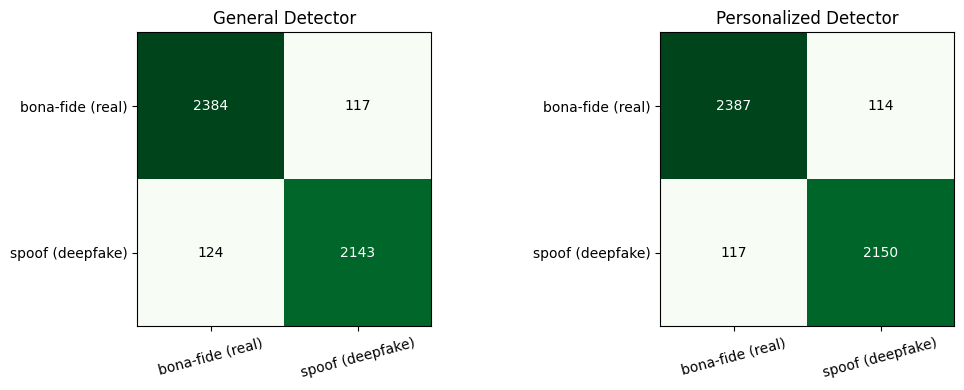

,metric,general,personalized,delta
0,accuracy,0.949455,0.951552,0.002097
1,f1,0.946764,0.949018,0.002254
2,precision,0.948230,0.949647,0.001417
3,recall,0.945302,0.948390,0.003088


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(axes, [general_preds, personalized_preds],
                            ["General Detector", "Personalized Detector"]):
    cm = confusion_matrix(true_labels, preds)
    im = ax.imshow(cm, cmap="Greens")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(list(INVERSE_LABEL_MAP.values()), rotation=15)
    ax.set_yticklabels(list(INVERSE_LABEL_MAP.values()))
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center",
                    color="white" if cm[r, c] > cm.max()/2 else "black")
    ax.set_title(title)
plt.tight_layout(); plt.show()

comparison_df = pd.DataFrame({
    "metric": ["accuracy", "f1", "precision", "recall"],
    "general": [
        accuracy_score(true_labels, general_preds),
        f1_score(true_labels, general_preds),
        precision_score(true_labels, general_preds),
        recall_score(true_labels, general_preds),
    ],
    "personalized": [
        accuracy_score(true_labels, personalized_preds),
        f1_score(true_labels, personalized_preds),
        precision_score(true_labels, personalized_preds),
        recall_score(true_labels, personalized_preds),
    ],
})
comparison_df["delta"] = comparison_df["personalized"] - comparison_df["general"]
comparison_df


In [36]:

from sklearn.metrics import precision_recall_curve

def eer_threshold(y_true, probs_spoof):
    fpr, tpr, thresholds = roc_curve(y_true, probs_spoof)
    fnr = 1 - tpr
    finite = np.isfinite(thresholds)
    thr, fpr_, fnr_ = thresholds[finite], fpr[finite], fnr[finite]
    srt = np.argsort(thr)
    thr, fpr_, fnr_ = thr[srt], fpr_[srt], fnr_[srt]
    f = interp1d(thr, fpr_ - fnr_)
    t = brentq(f, thr[0], thr[-1])
    eer = float(interp1d(thr, fpr_)(t))
    return t, eer

def best_f1_threshold(y_true, probs_spoof):
    prec, rec, thresh = precision_recall_curve(y_true, probs_spoof)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    best_i = np.argmax(f1[:-1])
    return thresh[best_i]

p_eer_t, p_eer = eer_threshold(true_labels, personalized_probs_spoof)
p_f1_t = best_f1_threshold(true_labels, personalized_probs_spoof)

print(f"Personalized model: EER={p_eer*100:.2f}% @ threshold={p_eer_t:.4f}  |  "
      f"best-F1 threshold={p_f1_t:.4f}\n")

print(f"--- Personalized model @ default 0.5 (what you saw before) ---")
print(classification_report(true_labels, personalized_preds, target_names=list(INVERSE_LABEL_MAP.values())))

print(f"--- Personalized model @ EER threshold ({p_eer_t:.4f}) ---")
preds_eer = (personalized_probs_spoof >= p_eer_t).astype(int)
print(classification_report(true_labels, preds_eer, target_names=list(INVERSE_LABEL_MAP.values())))

print(f"--- Personalized model @ best-F1 threshold ({p_f1_t:.4f}) ---")
preds_f1 = (personalized_probs_spoof >= p_f1_t).astype(int)
print(classification_report(true_labels, preds_f1, target_names=list(INVERSE_LABEL_MAP.values())))



Personalized model: EER=4.72% @ threshold=0.4167  |  best-F1 threshold=0.1255

--- Personalized model @ default 0.5 (what you saw before) ---
                  precision    recall  f1-score   support

bona-fide (real)       0.95      0.95      0.95      2501
spoof (deepfake)       0.95      0.95      0.95      2267

        accuracy                           0.95      4768
       macro avg       0.95      0.95      0.95      4768
    weighted avg       0.95      0.95      0.95      4768

--- Personalized model @ EER threshold (0.4167) ---
                  precision    recall  f1-score   support

bona-fide (real)       0.96      0.95      0.95      2501
spoof (deepfake)       0.95      0.95      0.95      2267

        accuracy                           0.95      4768
       macro avg       0.95      0.95      0.95      4768
    weighted avg       0.95      0.95      0.95      4768

--- Personalized model @ best-F1 threshold (0.1255) ---
                  precision    recall  f1-score 

In [37]:
test_df_ordered = test_df.iloc[order].reset_index(drop=True)

assert len(test_df_ordered) == len(true_labels), (
    f"Row count mismatch: test_df_ordered has {len(test_df_ordered)} rows but "
    f"true_labels has {len(true_labels)}. Re-run the Section 15 deployment "
    "simulation cell before this one."
)

submission_df = pd.DataFrame({
    "file":                    test_df_ordered["file"].values,
    "speaker":                 test_df_ordered["speaker"].values,
    "true_label":              test_df_ordered["label"].values,
    "general_pred_label":      [INVERSE_LABEL_MAP[p] for p in general_preds],
    "general_correct":         (general_preds == true_labels),
    "personalized_pred_label": [INVERSE_LABEL_MAP[p] for p in personalized_preds],
    "personalized_correct":    (personalized_preds == true_labels),
})

SUBMISSION_PATH = os.path.join(OUTPUT_DIR, "submission.csv")
submission_df.to_csv(SUBMISSION_PATH, index=False)

print(f"submission.csv saved → {SUBMISSION_PATH}")
print(f"Rows: {len(submission_df):,}")
submission_df.head(10)


submission.csv saved → outputs/submission.csv
Rows: 4,768


,file,speaker,true_label,general_pred_label,general_correct,personalized_pred_label,personalized_correct
0,53.wav,Boris Johnson,bona-fide,bona-fide (real),True,bona-fide (real),True
1,410.wav,Boris Johnson,bona-fide,bona-fide (real),True,bona-fide (real),True
2,437.wav,Boris Johnson,spoof,spoof (deepfake),True,spoof (deepfake),True
3,725.wav,Boris Johnson,bona-fide,bona-fide (real),True,bona-fide (real),True
4,778.wav,Boris Johnson,bona-fide,bona-fide (real),True,bona-fide (real),True
5,951.wav,Boris Johnson,bona-fide,bona-fide (real),True,bona-fide (real),True
6,1124.wav,Boris Johnson,bona-fide,bona-fide (real),True,bona-fide (real),True
7,1163.wav,Boris Johnson,bona-fide,bona-fide (real),True,bona-fide (real),True
8,1489.wav,Boris Johnson,spoof,spoof (deepfake),True,spoof (deepfake),True
9,1501.wav,Boris Johnson,bona-fide,bona-fide (real),True,bona-fide (real),True


In [38]:
mem_rows = memory_bank.conn.execute(
    "SELECT speaker_id, COUNT(*) as n_entries, AVG(confidence) as avg_conf, "
    "AVG(age_weight) as avg_age_weight, SUM(cluster_size) as total_raw_samples_represented "
    "FROM embeddings GROUP BY speaker_id ORDER BY n_entries DESC"
).fetchall()
mem_df = pd.DataFrame(mem_rows, columns=[
    "speaker_id", "n_entries", "avg_confidence", "avg_age_weight", "total_raw_samples_represented"
])
print(f"Speakers with at least one gated memory entry: {len(mem_df)}")
print(f"Speakers whose memory was prototype-compressed: "
      f"{(mem_df['total_raw_samples_represented'] > mem_df['n_entries']).sum()}")
mem_df.head(15)


Speakers with at least one gated memory entry: 16
Speakers whose memory was prototype-compressed: 11


,speaker_id,n_entries,avg_confidence,avg_age_weight,total_raw_samples_represented
0,Richard Nixon,29,0.999008,1.0,38
1,Boris Johnson,28,0.998848,1.0,38
2,Louis C.K.,27,0.997665,1.0,27
3,Nelson Mandela,25,0.996048,1.0,35
4,George W. Bush,25,0.999262,1.0,33
5,Mr. Rogers,24,0.998907,1.0,34
6,Mark Zuckerberg,24,0.999087,1.0,33
7,John Cleese,24,0.997972,1.0,33
8,Christopher Hitchens,24,0.998332,1.0,34
9,JFK,23,0.998188,1.0,33


In [39]:
print("Saved artifacts in", os.path.abspath(OUTPUT_DIR), ":")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)


Saved artifacts in /kaggle/working/outputs :
 - eda_fig1_waveform_stft_mel_mfcc.png
 - eda_fig2_delta_mfcc_cqt_cqcc.png
 - eda_fig3_spectral_zcr_rms_chroma_f0.png
 - eda_fig4_distributions.png
 - feat_test_v3.npz
 - feat_train_v3.npz
 - feat_val_v3.npz
 - memory_bank.sqlite
 - rat_embedding_model.pt
 - rat_personalized_head.pt
 - rat_training_history.png
 - submission.csv
